# 0DTE experimental lab (15:30 ATM package)

Same instrument, clocks, smear, and signal as
`atm_straddle_rv_iv.ipynb`. This notebook is the lab for:

1. ensembles of the seven models and of the two paper rules
   (including a causal PCR / spectral ensemble), plus extended causal
   PCA/PCR portfolios (§5b), supervised PLS/PCovR projections (§5c), and
   PCA structure diagnostics (§5d)
2. vol-space maps $\hat y\sqrt{B}$, $m\sqrt{B}$ (stand-in if
   `atm_straddle_volmap.ipynb` is not in the tree)
3. extra weighting rules (rank of $|s|$, inverse expanding vol of $R$)
4. an iron condor lab (§8–§12): width ladder, wing-cost / tail / IR
   diagnostics, strangle bodies with per-side attribution, the §5
   ensembles on the defined-risk instrument, and quoted-spread fill
   sensitivity
5. paired significance (HAC $t$ + block bootstrap) on the headline deltas
   (§13)
6. the defined-risk portfolio, parked in the RV–IV deck (§14): why wings on selling days do
   not pay per dollar of premium — wing-cost decomposition,
   quoted-spread fills, one-sided wings, a width ladder, and when the
   cap pays
7. cutting exposure on days yesterday's signal ranked high (§15): a
   stand-aside rule scored on the tail against a placebo — a negative
   result; the flag lands on buying days, not on the losses
8. the body itself (§16): a same-strike straddle against the deck's
   nearest out-of-the-money pair — one dollar P&L in three frames, the
   five-point vertical that separates them, offset, fills, and the
   estimated-fraction wealth rule (parked in the main notebook); the
   strangle body stays

$R \sim a + b\,s$ lives in `atm_straddle_rv_iv.ipynb`. Sections are
numbered to mirror the main notebook's; §2–§4 have no counterpart here,
so the numbering runs 1, 5, 5b–5d, 6, … .

Published mid-fill rule tables stay in the RV–IV notebook. Intraday
bars stay in `atm_straddle_intraday.ipynb`.

In [1]:
import hashlib
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Chain, nearest-OTM package, $R$, forecasts, signal

Same construction as the RV-IV deck, and the same two data rules. Twelve
days in the file are half sessions (a 13:00 close, with the 13:00
quotes carried forward to a full grid, so the "15:30" row sits after expiry):
they are dropped by the shared library filter and listed below, six of
them inside the scored range and five of those scored days before the
filter. The nearest-OTM pick is guarded against
vendor outages — a stamp with almost no live contracts, or a nearest
strike more than ten points from the index level, is not a package —
and a leg quoted `bid == ask == 0` carries no price, so its mid is
missing rather than zero. The vendor's implied-volatility field is a
bisection on a bracket that reports a bracket node when it does not
converge; those legs are censored and the day's implied variance is
recovered by inverting the package midpoint through Black-Scholes-Merton
over the remaining half hour, as in the deck's §8 — the five COVID cap
days are kept, not dropped. The common frame is the intersection of the
eight forecast tables' scored days, and a gate checks that it is the
deck's scored frame day for day; every table in this notebook is scored
on it.

**Benchmark and panel.** The benchmark everywhere in this notebook is
the FOMC-panel ridge — `block-diagonal ridge`, the ridge of record — and every
single-model row labelled `blk2` is that model. The panel of record is
the FOMC panel: the ridge and the fixed-penalty lasso are estimated on
it. The diagnostic row `blk2_inc` is the same ridge on the earlier
panel, which carries no FOMC columns, so the pair isolates what the
calendar channels contribute.
The four remaining comparators (the two tree models, the causally tuned
lasso, and the elastic net) are still on the earlier panel, pending a
re-run on the FOMC panel; their rows are read as comparators, not as
like-for-like panel-matched entries. The model set, its order, and its
labels come from `asl.MODEL_ORDER` / `asl.YHAT_LABEL`, so this notebook
enumerates whatever the library defines.

**What the diagnostic row may and may not enter.** `blk2_inc` is a
diagnostic, not a forecast. The ensembles of §5, the causal PCA/PCR and
supervised PLS/PCovR labs of §5b–§5c, the correlation and
sign-agreement matrices, the near-duplicate list and the participation
ratio all run on the seven forecasts and exclude it; the notebook
holds that set as `MODELS`. The plain per-model tables — the extra
weights of §7, the wing ladder of §14, the risk-flag scoreboards of
§15, the body comparison of §16 — still carry all eight rows with
the diagnostic labelled as such.

**Annualization.** Every Sharpe ratio and information ratio here scales
a per-observation statistic by $\sqrt{252}$ (`asl.PERIODS_PER_YEAR`),
one row per trade day. The 0DTE frame does not trade 252 days a year
over this window — SPXW listed Monday/Wednesday/Friday expirations
before June 2022 — so the cell prints the realized trade days per year
and the factor that converts to calendar time.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid", "underlying_price",
        "impl_volatility", "hours_to_expiration"]
_st = os.stat(path)
# same cache name and column list as the RV-IV deck, so the two notebooks share one cached slice
_ck = CACHE / f"chain_15301600v2_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))].unique()
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
codes, uts = pd.factorize(chain["timestamp"])
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where((uet.hour == 15) & (uet.minute == 30), "15:30",
              np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"))
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
del chain
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
# Half sessions: the market closed at 13:00 and the vendor carried the 13:00 quotes forward to a
# full grid, so the "15:30" row is a post-close placeholder and the chain's own hours-to-expiration
# is <= 0 there. The shared library rule drops the whole day; every notebook applies it.
half_days = asl.early_close_days(e)
print("half sessions in the file:", len(half_days), [str(d.date()) for d in half_days])
e = e[~pd.to_datetime(e["expiration"]).dt.normalize().isin(half_days)].copy()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()   # bid == ask == 0 is a no-quote sentinel: mid == 0 is excluded here
spot = live.dropna(subset=["underlying_price"]).groupby("expiration")["underlying_price"].first()
# guarded nearest-OTM pick: a stamp with too few live contracts, or a nearest strike more than
# ATM_MAX_STRIKE_GAP points away (more than one strike missing), is a vendor outage, not a package
atm, atm_dropped = asl.pick_nearest_otm_guarded(live, spot)
print(f"nearest-OTM cells dropped by the outage guards: {len(atm_dropped)}")
if len(atm_dropped):
    _d = atm_dropped.copy()
    _d["date"] = pd.to_datetime(_d["expiration"]).dt.date
    print(_d[["date", "S", "K_c", "K_p", "gap", "n_live", "reason"]].to_string(index=False))
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)

def load_gspc_close(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            return cached.astype(float)
    raw = yf.download("^GSPC", start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
                      end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
                      auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close.rename("close").to_frame().to_parquet(cp)
    return close.astype(float)

exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))
atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
# Implied variance, built exactly as the RV-IV deck builds it. The vendor's implied-volatility
# field is a bisection on a bracket and reports a bracket NODE when it does not converge, so a leg
# sitting on a node carries no information: censor_vendor_iv sets those legs to NaN, and on the
# affected days the package midpoint is inverted through Black-Scholes-Merton over the remaining
# half hour instead of being dropped. Dropping them instead would lose the five COVID cap days.
# The node test is an EXACT hit (asl.IV_NODE_RTOL = 1e-5, float32 rounding): the middle node sits
# at 0.0035 per hour, an ordinary implied volatility, so a wider band censors genuine quotes.
atm = asl.attach_iv_hourly_as_30min(atm)


def _on_node(v):
    v = pd.to_numeric(v, errors="coerce")
    return v.notna() & asl.censor_vendor_iv(v).isna()   # library default rtol = asl.IV_NODE_RTOL


iv_capped = (_on_node(atm["impl_volatility_c"]) | _on_node(atm["impl_volatility_p"])) & (atm["entry"] > 0)
_inv30 = pd.Series(
    [asl.bsm_invert_package_vol(S_, Kc_, Kp_, m_, hours_remaining=0.5)
     for S_, Kc_, Kp_, m_ in zip(atm.loc[iv_capped, "S"], atm.loc[iv_capped, "K_c"],
                                 atm.loc[iv_capped, "K_p"], atm.loc[iv_capped, "entry"])],
    index=atm.index[iv_capped], dtype=float)
atm.loc[iv_capped, "iv_hourly"] = _inv30.map(asl.hourly_iv_from_total_vol)
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
print(f"days with a censored implied-volatility leg (exact node hits, rtol {asl.IV_NODE_RTOL:g}): "
      f"{int(iv_capped.sum())} {[str(d.date()) for d in atm.index[iv_capped]]}")
print(f"  recovered by inverting the package midpoint: {int(np.isfinite(atm.loc[iv_capped, 'iv_hourly']).sum())}; "
      f"days still without a usable implied volatility: {int(atm['iv_hourly'].isna().sum())}")

from concurrent.futures import ThreadPoolExecutor
YHATS = asl.yhat_paths(REPO)
need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {tag: pool.submit(asl.load_yhat_1530_mz_cached, tag, path, need_dates, CACHE)
            for tag, path in YHATS.items()}
    models = {tag: futs[tag].result() for tag in YHATS}
LABEL = asl.YHAT_LABEL
MODEL_ORDER = list(asl.MODEL_ORDER)          # every table, including the diagnostic row
MODELS = [t for t in MODEL_ORDER if t != "blk2_inc"]   # the forecasts: ensembles and cross-model statistics

books = {}
for tag, rv in models.items():
    px = atm.join(rv[["rv_hat", "yhat", "m", "yhat_vol", "m_vol", "rv_raw", "baseline"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    books[tag] = px
common = None
for tag in MODEL_ORDER:
    common = books[tag].index if common is None else common.intersection(books[tag].index)
common = common.sort_values()
print("common days", len(common), pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))
# the half sessions that sit inside the scored range are the ones the frame loses to this rule
inside = [str(d.date()) for d in half_days if pd.Timestamp(common.min()) <= d <= pd.Timestamp(common.max())]
print(f"half sessions inside the scored range: {len(inside)}", inside)
print("  five of them were scored days before this filter; 2021-11-26 never was — the tape stopped "
      "at 14:00 that day, so it has no 16:00 forecast row")
assert inside == ["2020-11-27", "2020-12-24", "2021-11-26", "2022-11-25",
                  "2023-07-03", "2023-11-24"], inside
# frame gate: this notebook benchmarks the RV-IV deck, so it must score the deck's days exactly
deck_daily = pd.read_parquet(OUT / "daily_blk2.parquet")
print("deck daily_blk2 days", len(deck_daily), "| common days", len(common))
assert set(common) == set(deck_daily.index), sorted(
    str(d.date()) for d in set(common) ^ set(deck_daily.index))
# The two builds are the same package on the same days, but they read the leg midpoint from
# different places: the library helper rebuilds it as (bid + ask) / 2 through quote_mid, so that a
# bid == ask == 0 leg has no price, while the deck reads the vendor's own mid column. The two agree
# to quote rounding, which is the tolerance every cross-check against the deck uses below.
deck_ref = (deck_daily["pos"] * deck_daily["R"]).loc[common]
_dR = float((books["blk2"].loc[common, "R"] - deck_daily.loc[common, "R"]).abs().max())
_dq = int((books["blk2"].loc[common, "pos"] != deck_daily.loc[common, "pos"]).sum())
print(f"frame gate: the common frame is the deck's scored frame, day for day; "
      f"positions differ on {_dq} days, max |R - deck R| {_dR:.2e} (quote rounding)")
assert _dq == 0 and _dR < 1e-5
# annualization convention behind every sqrt(PERIODS_PER_YEAR) in this notebook (asl.PERIODS_PER_YEAR)
_tpy = asl.trades_per_year(common)
print(f"annualization: per trade day, PERIODS_PER_YEAR {asl.PERIODS_PER_YEAR:g}; this frame trades "
      f"{_tpy:.1f} days a year, so the calendar-time equivalent scales by "
      f"sqrt({_tpy:.1f}/{asl.PERIODS_PER_YEAR:g}) = {np.sqrt(_tpy / asl.PERIODS_PER_YEAR):.3f}")


half sessions in the file: 12 ['2020-11-27', '2020-12-24', '2021-11-26', '2022-11-25', '2023-07-03', '2023-11-24', '2024-07-03', '2024-11-29', '2024-12-24', '2025-07-03', '2025-11-28', '2025-12-24']


nearest-OTM cells dropped by the outage guards: 0
days with a censored implied-volatility leg (exact node hits, rtol 1e-05): 5 ['2020-03-13', '2020-03-16', '2020-03-18', '2020-03-20', '2020-03-23']
  recovered by inverting the package midpoint: 5; days still without a usable implied volatility: 0


common days 866 2020-01-03 00:00:00 -> 2024-04-30 00:00:00
half sessions inside the scored range: 6 ['2020-11-27', '2020-12-24', '2021-11-26', '2022-11-25', '2023-07-03', '2023-11-24']
  five of them were scored days before this filter; 2021-11-26 never was — the tape stopped at 14:00 that day, so it has no 16:00 forecast row
deck daily_blk2 days 866 | common days 866
frame gate: the common frame is the deck's scored frame, day for day; positions differ on 0 days, max |R - deck R| 1.95e-07 (quote rounding)
annualization: per trade day, PERIODS_PER_YEAR 252; this frame trades 200.3 days a year, so the calendar-time equivalent scales by sqrt(200.3/252) = 0.892


## 5. Ensemble of the seven models

(a) mean $s$ then sign. (b) majority vote of sign. (c) equal-weight
average of the seven $\mathrm{sign}(s)$ positions $q$. (d) trailing-Sharpe
and trailing-IR weights on those positions (expanding 63, lag 1). (e)
causal spectral / PCR ensemble of the seven signals (below). Also an
equal-weight mix of the two paper rules on blk2.

**Spectral / PCR.** Let $X_t\in\mathbb{R}^{7}$ be the vector of model
signals $s=\widehat{RV}-\mathrm{IV}_{30}^{2}$ on day $t$. On days
$u<t$ (min 63) standardise each signal by its own past mean and
standard deviation — a correlation PCA, so that a model's dispersion
does not decide its loading — take the SVD, and read day $t$ onto the
leading $k$ right singular vectors. Two portfolios:

- *spectral PC1:* $s^{\mathrm{pc1}}_t$ is the PC1 score; sign is
  flipped so PC1 co-moves with the cross-sectional mean $s$. Position
  is $\mathrm{sign}(s^{\mathrm{pc1}})$. The score is centred on its
  trailing mean, so the position asks whether today's consensus sits
  above its own past average, not whether the consensus gap is
  positive. For the first 63 days, before the SVD is fitted, the same
  demeaned rule is applied with the equal-weight direction in place of
  the eigenvector.
- *PCR $k=1,2$:* regress $R_u$ on the lagged PC scores, apply the
  coefficients to day $t$. Position is $\mathrm{sign}(\hat R_t)$.

The SVD and the PCR fit use only $u<t$. Full-sample eigenvalues are
printed as a diagnostic, not used to trade. The set is the seven
forecasts; the no-FOMC ridge is a diagnostic row and is not in it. The
seven signals are still far from seven votes: the ridge and the
fixed-penalty lasso on the same panel are near-duplicates, and the two
tree models are close as well; the participation ratio of the
correlation eigenvalues puts the effective count far below
7 — the cell prints the correlations, the near-duplicate
pairs, and the participation ratio, and the vote and mean rows should
be read with them.
Every table carries the mean absolute position, so rows with different
gross exposure are not compared as if they were the same size.

full-sample variance share (diagnostic)
PC1    0.682378
PC2    0.161817
PC3    0.121500
PC4    0.028806
PC5    0.003822
PC6    0.001134
PC7    0.000543
full-sample loadings (sign of PC1 aligned to mean s)
                                    PC1       PC2
baseline (HAR + calendar OLS)  0.097197 -0.815210
block-diagonal ridge           0.412575 -0.286109
LightGBM                       0.385434  0.354282
XGBoost                        0.352321  0.270646
lasso (causally tuned)         0.419944  0.013599
lasso (fixed 1e-4)             0.431298 -0.205197
elastic net (causally tuned)   0.430435  0.111890


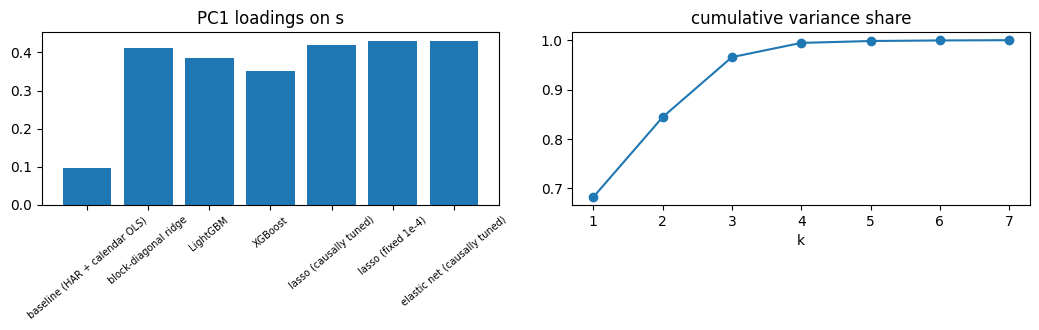

                                    n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy  mean_abs_q
mean-s then sign           866.000000  0.105035  1.122799  -5.422480 -0.652561  0.160853  0.899141  10.316049  0.967725  10.594866  2.752914    1.485025  313.000000  36.143187    1.000000
majority vote              866.000000  0.101946  1.123084  -5.422480 -0.660700  0.137295  0.913145  10.316049  0.986256  10.587764  2.671259    1.440978  319.000000  36.836028    1.000000
EW sign(s) q               866.000000  0.093108  0.967741  -5.422480 -0.428571  0.086420  0.687091  10.316049  1.155480  16.387361  2.831320    1.527321  319.000000  36.836028    0.836358
trail-Sharpe sign(s) q     866.000000  0.092709  0.982579  -5.422480 -0.428571  0.058812  0.704095  10.316049  1.117853  15.447794  2.776614    1.497810  293.000000  33.833718    0.842075
trail-IR sign(s) q         866.000000  0.092661  0.981256  -

In [3]:
sig = pd.DataFrame({tag: books[tag]["signal"].loc[common] for tag in MODELS})
pos = np.sign(sig).replace(0.0, -1.0)
R = books["blk2"]["R"].loc[common]

ens, ens_q = {}, {}   # daily returns, and the position series that produced them


def _add(name, q):
    ens_q[name] = pd.Series(q, index=sig.index).astype(float)
    ens[name] = ens_q[name] * R


_add("mean-s then sign", np.sign(sig.mean(axis=1)).replace(0.0, -1.0))
_add("majority vote", np.sign(pos.sum(axis=1)).replace(0.0, -1.0))
_add("EW sign(s) q", pos.mean(axis=1))

def trailing_w(q: pd.DataFrame, kind: str) -> pd.Series:
    idx = q.index
    out = pd.Series(0.0, index=idx)
    for i, t in enumerate(idx):
        if i < 63:
            w = np.ones(q.shape[1]) / q.shape[1]
        else:
            sl = slice(0, i)
            scores = []
            for col in q.columns:
                rp = (q[col] * R).iloc[sl]
                mu, sd = float(rp.mean()), float(rp.std(ddof=1))
                if kind == "sharpe":
                    scores.append(mu / sd if sd > 0 else 0.0)
                else:
                    active = rp - (-R.iloc[sl])
                    a_sd = float(active.std(ddof=1))
                    scores.append(float(active.mean()) / a_sd if a_sd > 0 else 0.0)
            w = np.maximum(np.array(scores, float), 0.0)
            w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
        out.iloc[i] = float((q.iloc[i] * w).sum())
    return out

_add("trail-Sharpe sign(s) q", trailing_w(pos, "sharpe"))
_add("trail-IR sign(s) q", trailing_w(pos, "ir"))
blk_sizes = asl.rule_sizes(books["blk2"])
_add("blk2 0.5 AS + 0.5 sign(s)", (blk_sizes["always short"] + blk_sizes["sign(s)"]).loc[common] / 2.0)
_add("blk2 sign(s)", blk_sizes["sign(s)"].loc[common])
_add("always short", blk_sizes["always short"].loc[common])

# Causal spectral / PCR ensemble of the model-signal vector (len(MODELS) wide; the
# diagnostic no-FOMC ridge is not a forecast and never enters an ensemble).
# Day t sees only X[:t] (strict). Min 63 days; earlier days use the same demeaned
# rule with the equal-weight direction in place of the eigenvector.
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape


def _past_scale(past):
    # correlation PCA: each column centred and scaled by its own past mean and standard deviation
    mu = past.mean(axis=0)
    sd = past.std(axis=0, ddof=1) if len(past) > 1 else np.ones(past.shape[1])
    return mu, np.where(sd > 0, sd, 1.0)


def _warmup_score(Xm, t):
    # demeaned consensus: today's vector minus the mean of the past days, averaged across models
    mu0 = Xm[:t].mean(axis=0) if t > 0 else Xm[t]
    return float((Xm[t] - mu0).mean())


s_pc1 = np.full(n, np.nan)
rhat_k1 = np.full(n, np.nan)
rhat_k2 = np.full(n, np.nan)
loadings_last = None
for t in range(n):
    if t < 63:
        s_pc1[t] = _warmup_score(X, t)
        rhat_k1[t] = s_pc1[t]
        rhat_k2[t] = s_pc1[t]
        continue
    past = X[:t]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    # economy SVD on T x 7
    _, S_sing, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    if np.dot(v1, np.ones(p)) < 0:
        v1 = -v1
        Vt = Vt.copy()
        Vt[0] = v1
    xt = (X[t] - mu) / sd
    z1 = float(xt @ Vt[0])
    z2 = float(xt @ Vt[1])
    s_pc1[t] = z1
    Z1 = Xc @ Vt[0]
    Z2 = np.column_stack([Z1, Xc @ Vt[1]])
    y = r[:t]
    def ols_apply(Z, y, znew):
        Z1c = np.column_stack([np.ones(len(y)), Z])
        beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
        z = np.concatenate([[1.0], np.atleast_1d(znew)])
        return float(z @ beta)
    rhat_k1[t] = ols_apply(Z1, y, z1)
    rhat_k2[t] = ols_apply(Z2, y, [z1, z2])
    loadings_last = (S_sing, Vt)

s_pc1 = pd.Series(s_pc1, index=sig.index)
rhat_k1 = pd.Series(rhat_k1, index=sig.index)
rhat_k2 = pd.Series(rhat_k2, index=sig.index)
q_pc1 = np.sign(s_pc1).replace(0.0, -1.0)
q_pcr1 = np.sign(rhat_k1).replace(0.0, -1.0)
q_pcr2 = np.sign(rhat_k2).replace(0.0, -1.0)
_add("spectral PC1 sign", q_pc1)
_add("PCR k=1 sign", q_pcr1)
_add("PCR k=2 sign", q_pcr2)

# Full-sample SVD diagnostic only (not a trading input); correlation scale as above.
Xc_all = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
_, S_all, Vt_all = np.linalg.svd(Xc_all, full_matrices=False)
share = S_all**2 / (S_all**2).sum()
load_tab = pd.DataFrame(Vt_all[:2].T, index=[LABEL[t] for t in MODELS], columns=["PC1", "PC2"])
if np.dot(load_tab["PC1"], np.ones(p)) < 0:
    load_tab["PC1"] *= -1
print("full-sample variance share (diagnostic)")
print(pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_string())
print("full-sample loadings (sign of PC1 aligned to mean s)")
print(load_tab.to_string())
load_tab.to_csv(OUT / "ensemble_spectral_loadings.csv")
pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_csv(OUT / "ensemble_spectral_varshare.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].bar(load_tab.index, load_tab["PC1"].to_numpy())
axes[0].set_title("PC1 loadings on s")
axes[0].tick_params(axis="x", rotation=40, labelsize=7)
axes[1].plot(np.arange(1, p + 1), share.cumsum(), marker="o")
axes[1].set_title("cumulative variance share")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(OUT / "ensemble_spectral_pca.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

ens_tab = pd.DataFrame({k: asl.rule_row(v, ens_q[k]) for k, v in ens.items()}).T
ens_tab["mean_abs_q"] = pd.Series({k: float(q.abs().mean()) for k, q in ens_q.items()})
print(ens_tab.to_string())
# effective breadth of the signals: participation ratio of the correlation eigenvalues
_corr = sig.corr()
_ev = np.linalg.eigvalsh(_corr.to_numpy())
_n_eff = float(_ev.sum() ** 2 / (_ev**2).sum())
_dups = [(LABEL[a], LABEL[b], round(float(_corr.loc[a, b]), 3))
         for i, a in enumerate(MODELS) for b in list(MODELS)[i + 1:] if float(_corr.loc[a, b]) > 0.98]
print(f"effective number of independent signals (participation ratio): {_n_eff:.2f} of {p}")
print("near-duplicate pairs (correlation > 0.98):", _dups)
ens_tab.to_csv(OUT / "ensemble_summary.csv")
pd.DataFrame(ens).to_csv(OUT / "ensemble_daily.csv")
print("saved ensemble_*.csv")


## 5b. Causal PCA/PCR portfolios — where the ensemble information lives

Extensions of the §5 spectral machinery, same protocol throughout: day
$t$ uses the SVD of the signal matrix on days $u<t$ only, each signal
standardised by its own past mean and standard deviation (min 63;
earlier days use the same demeaned-consensus rule as §5), and PC1's
sign co-moves with the cross-sectional mean $s$. Nothing here is a
search for a better rule — the table maps where the ensemble
information lives.

- *PCR $k$-sweep:* regress $R_u$ on the first $k$ lagged PC scores,
  $k=1,\dots,7$, apply the coefficients to day $t$, trade
  $\mathrm{sign}(\hat R_t)$. Fitted values are invariant to component
  sign flips, so the sweep needs no convention beyond PC1's.
- *PC2 / PC3 sign portfolios:* $q_t=\mathrm{sign}(\hat\beta_{j,t})\,
  \mathrm{sign}(z_{j,t})$, where $\hat\beta_{j,t}$ is the OLS slope of
  $R_u$ on the past PC$_j$ scores — the sign convention is itself
  estimated only from $u<t$.
- *PC1-of-$q$:* the same causal PC1 taken on the 7-vector of signed
  positions $q=\mathrm{sign}(s)$ instead of raw $s$; trade the sign of
  the score.

Benchmarks repeat from §5. The first three rows reproduce the §5 portfolios
exactly; the in-cell check prints the max $|R'|$ discrepancy against
`ens`.

In [4]:
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape
scores = np.full((n, p), np.nan)
bsign = np.ones((n, p))
rhat_k = {k: np.full(n, np.nan) for k in range(1, p + 1)}
for t in range(n):
    if t < 63:
        ew = _warmup_score(X, t)
        scores[t, :] = ew
        for k in rhat_k:
            rhat_k[k][t] = ew
        continue
    past = X[:t]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    if np.dot(Vt[0], np.ones(p)) < 0:
        Vt = Vt.copy()
        Vt[0] = -Vt[0]
    xt = (X[t] - mu) / sd
    z = xt @ Vt.T
    Z = Xc @ Vt.T
    scores[t] = z
    y = r[:t]
    for j in range(p):
        bsign[t, j] = 1.0 if float(Z[:, j] @ y) >= 0 else -1.0
    ones = np.ones((t, 1))
    for k in range(1, p + 1):
        Zk = np.column_stack([ones, Z[:, :k]])
        beta, *_ = np.linalg.lstsq(Zk, y, rcond=None)
        rhat_k[k][t] = float(np.concatenate([[1.0], z[:k]]) @ beta)

idx = sig.index
s_pc1x = pd.Series(scores[:, 0], index=idx)
rhat = {k: pd.Series(v, index=idx) for k, v in rhat_k.items()}


def _sgn(x):
    return np.sign(x).replace(0.0, -1.0)


pca_books, pca_q = {}, {}


def _add_pca(name, q):
    pca_q[name] = pd.Series(q, index=idx).astype(float)
    pca_books[name] = pca_q[name] * R


_add_pca("spectral PC1 sign", _sgn(s_pc1x))
for k in range(1, p + 1):
    _add_pca(f"PCR k={k} sign", _sgn(rhat[k]))
for j in (1, 2):
    zj = pd.Series(scores[:, j] * bsign[:, j], index=idx)
    _add_pca(f"PC{j+1} sign (beta-aligned)", _sgn(zj))

# Causal PC1 on the vector of signed positions q = sign(s), same standardisation and warm-up rule.
Xq = pos.to_numpy(float)
s_q1 = np.full(n, np.nan)
for t in range(n):
    if t < 63:
        s_q1[t] = _warmup_score(Xq, t)
        continue
    past = Xq[:t]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    s_q1[t] = float(((Xq[t] - mu) / sd) @ v1)
s_q1 = pd.Series(s_q1, index=idx)
_add_pca("PC1-of-q sign", _sgn(s_q1))

for k_ in ("EW sign(s) q", "blk2 sign(s)", "always short"):
    pca_q[k_] = ens_q[k_]
    pca_books[k_] = ens[k_]

chk = max(
    float((pca_books[k_] - ens[k_]).abs().max())
    for k_ in ("spectral PC1 sign", "PCR k=1 sign", "PCR k=2 sign")
)
print("max |R' diff| vs the §5 portfolios:", chk)
pca_tab = pd.DataFrame({k: asl.rule_row(v, pca_q[k]) for k, v in pca_books.items()}).T
pca_tab["mean_abs_q"] = pd.Series({k: float(q.abs().mean()) for k, q in pca_q.items()})
print(pca_tab.to_string())
pca_tab.to_csv(OUT / "pca_lab_books.csv")
print("saved", OUT / "pca_lab_books.csv")


max |R' diff| vs the §5 portfolios: 0.0
                                  n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy  mean_abs_q
spectral PC1 sign        866.000000  0.032678  1.127233  -6.836034 -0.844728 -0.069418  0.694677  10.316049  1.339215  10.631202  0.853107    0.460198  506.000000  58.429561    1.000000
PCR k=1 sign             866.000000 -0.065893  1.125778 -10.316049 -0.779274 -0.013082  0.798385   4.626674 -1.565978  10.474738 -1.722458   -0.929159  426.000000  49.191686    1.000000
PCR k=2 sign             866.000000 -0.052112  1.126501 -10.316049 -0.754291  0.030051  0.808932   4.626674 -1.567397  10.523895 -1.361336   -0.734356  390.000000  45.034642    1.000000
PCR k=3 sign             866.000000 -0.042132  1.126918 -10.316049 -0.749960  0.058943  0.813642   4.626674 -1.586117  10.560942 -1.100228   -0.593504  378.000000  43.648961    1.000000
PCR k=4 sign             866.0

## 5c. Causal supervised projections (PLS / PCovR)

Section 5's PC1/PCR portfolios are unsupervised: the direction is chosen by
the variance of the seven signals, and $R$ enters only through the PCR
coefficients. Here the *direction itself* is supervised, with the same
strict causality as §5 (day $t$ uses $X_{u<t}$, $R_{u<t}$ only, each
signal standardised on that past; min 63; earlier days use the §5
warm-up rule). Nothing here is a search for a better rule — it maps
whether supervision adds anything over PC1. The lab's standing result is
that no ensemble beats the block-diagonal ridge $\mathrm{sign}(s)$
portfolio *significantly* (§13), so a null is the expected answer.

- *PLS1:* $w\propto X_c^{\top}R_c$ (the covariance-with-target
  direction), $\|w\|=1$; score $z_t=(x_t-\mu)^{\top}w$. Portfolio:
  $\mathrm{sign}(z)$.
- *PLS2:* one NIPALS deflation ($X_c^{(2)}=X_c-t_1p_1^{\top}$,
  $w_2\propto X_c^{(2)\top}R_c$), then OLS of $R$ on $[z_1,z_2]$ with
  intercept, applied to day $t$ — the supervised analog of PCR $k=2$.
  Portfolio: $\mathrm{sign}(\hat R_t)$.
- *PCovR blend:* leading eigenvector of
  $\alpha\,G_1/\mathrm{tr}\,G_1+(1-\alpha)\,G_2/\mathrm{tr}\,G_2$ with
  $G_1=(X_c^{\top}R_c)(X_c^{\top}R_c)^{\top}$, $G_2=X_c^{\top}X_c$,
  $\alpha\in\{0.25,0.5,0.75\}$; each Gram is normalized by its trace so
  the mix is scale-free. Sign aligned so the score co-moves with the
  PLS1 direction. Portfolio: $\mathrm{sign}(z)$.

Columns as in §5's ensemble table (`asl.rule_row`; daily portfolio,
$\sqrt{252}$). Benchmarks are pulled from §5's `ens` dict, not
recomputed.

In [5]:
PLS_ALPHAS = (0.25, 0.5, 0.75)
z_pls1 = np.full(n, np.nan)
rhat_pls2 = np.full(n, np.nan)
z_pcovr = {a: np.full(n, np.nan) for a in PLS_ALPHAS}

def _ols_apply(Z, y, znew):
    Z1c = np.column_stack([np.ones(len(y)), Z])
    beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
    z = np.concatenate([[1.0], np.atleast_1d(znew)])
    return float(z @ beta)

for t in range(n):
    if t < 63:
        ew = _warmup_score(X, t)
        z_pls1[t] = ew
        rhat_pls2[t] = ew
        for a in PLS_ALPHAS:
            z_pcovr[a][t] = ew
        continue
    past = X[:t]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    y = r[:t]
    yc = y - y.mean()
    xt = (X[t] - mu) / sd

    # PLS1: covariance-with-target direction, unit norm.
    w1 = Xc.T @ yc
    nw = float(np.linalg.norm(w1))
    w1 = np.ones(p) / np.sqrt(p) if nw == 0 else w1 / nw
    z1 = float(xt @ w1)
    z_pls1[t] = z1

    # PLS2: one NIPALS deflation, then OLS of R on [z1, z2] with intercept.
    T1 = Xc @ w1
    tt = float(T1 @ T1)
    p1 = Xc.T @ T1 / tt if tt > 0 else np.zeros(p)
    Xc2 = Xc - np.outer(T1, p1)
    w2 = Xc2.T @ yc
    nw2 = float(np.linalg.norm(w2))
    w2 = np.zeros(p) if nw2 == 0 else w2 / nw2
    z2 = float((xt - float(xt @ w1) * p1) @ w2)
    rhat_pls2[t] = _ols_apply(np.column_stack([T1, Xc2 @ w2]), y, [z1, z2])

    # PCovR blend: leading eigenvector of the trace-normalized Gram mix.
    g = Xc.T @ yc
    G1 = np.outer(g, g)
    G2 = Xc.T @ Xc
    tr1, tr2 = float(np.trace(G1)), float(np.trace(G2))
    for a in PLS_ALPHAS:
        M = np.zeros((p, p))
        if tr1 > 0:
            M = M + a * G1 / tr1
        if tr2 > 0:
            M = M + (1.0 - a) * G2 / tr2
        _, vecs = np.linalg.eigh(M)
        v = vecs[:, -1]
        ref = g if float(np.linalg.norm(g)) > 0 else np.ones(p)
        if float(v @ ref) < 0:
            v = -v
        z_pcovr[a][t] = float(xt @ v)

z_pls1 = pd.Series(z_pls1, index=sig.index)
rhat_pls2 = pd.Series(rhat_pls2, index=sig.index)

sup, sup_q = {}, {}


def _add_sup(name, q):
    sup_q[name] = pd.Series(q, index=sig.index).astype(float)
    sup[name] = sup_q[name] * R


q_pls1 = np.sign(z_pls1).replace(0.0, -1.0)
_add_sup("PLS1 sign", q_pls1)
_add_sup("PLS2 rhat sign", np.sign(rhat_pls2).replace(0.0, -1.0))
for a in PLS_ALPHAS:
    za = pd.Series(z_pcovr[a], index=sig.index)
    _add_sup(f"PCovR a={a} sign", np.sign(za).replace(0.0, -1.0))
for k in ("PCR k=1 sign", "spectral PC1 sign", "EW sign(s) q",
          "blk2 sign(s)", "always short"):
    sup_q[k] = ens_q[k]
    sup[k] = ens[k]

pls_tab = pd.DataFrame({k: asl.rule_row(v, sup_q[k]) for k, v in sup.items()}).T
pls_tab["mean_abs_q"] = pd.Series({k: float(q.abs().mean()) for k, q in sup_q.items()})
print(pls_tab.to_string())
pls_tab.to_csv(OUT / "pca_lab_pls.csv")
n_flip = int((np.sign(pd.Series(z_pcovr[0.25], index=sig.index))
              != np.sign(pd.Series(z_pcovr[0.75], index=sig.index))).sum())
print("PCovR sign flips between a=0.25 and a=0.75:", n_flip)
print("saved", OUT / "pca_lab_pls.csv")


                            n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy  mean_abs_q
PLS1 sign          866.000000 -0.065987  1.125772 -10.316049 -0.744282  0.093409  0.819002   3.550905 -1.877889  10.400954 -1.724918   -0.930486  312.000000  36.027714    1.000000
PLS2 rhat sign     866.000000 -0.040286  1.126986 -10.316049 -0.747553  0.060575  0.813642   4.626674 -1.589924  10.568263 -1.051943   -0.567458  377.000000  43.533487    1.000000
PCovR a=0.25 sign  866.000000 -0.074302  1.125253 -10.316049 -0.749960  0.056057  0.810802   3.550905 -1.819120  10.380594 -1.943168   -1.048218  352.000000  40.646651    1.000000
PCovR a=0.5 sign   866.000000 -0.062049  1.125996 -10.316049 -0.744282  0.082397  0.823170   3.550905 -1.861773  10.422374 -1.621636   -0.874771  332.000000  38.337182    1.000000
PCovR a=0.75 sign  866.000000 -0.058358  1.126194 -10.316049 -0.741996  0.101321  0.823170   3.55090

## 5d. PCA structure diagnostics

How much structure is there in the seven signals, and how many
independent bets are the seven portfolios? **Diagnostics only — nothing
here is a trading input.** Six views:

- *Correlation / sign agreement.* Pearson correlation of the daily
  $s$ vectors and pairwise sign-agreement %. Answers: how far from
  one signal are the seven models?
- *Expanding causal PC1 share.* At each $t\ge 63$, PC1 variance share
  of the SVD of $X_{u<t}$ on the correlation scale (each signal
  standardised by its past mean and standard deviation, as in §5) —
  the factor strength a day-$t$ trader would have seen. Answers: does the one-factor structure
  strengthen or decay?
- *Loading stability.* PC1 loadings at expanding cutoffs
  (every 21 days). Answers: does any model rotate in or out of the
  factor?
- *Risk-space PCA.* Full-sample PCA of the seven $\mathrm{sign}(s)$
  portfolio returns $q_i R$. Answers: how many independent bets are the seven
  portfolios in return space?
- *PC1 vs mean.* Full-sample PC1 score against the cross-sectional
  mean $s$. Answers: is PC1 anything other than the equal-weight
  mean?
- *$R^2$ ladder.* Full-sample $R^2$ of daily $R$ on the first $k$ PC
  scores, $k=1..7$ — the in-sample ceiling for the causal PCR portfolios
  of §5.

Pearson correlation of daily signals s (diagnostic)
               a0      blk2      lgbm       xgb   lasso_t   lasso_f      enet
a0       1.000000  0.342877  0.018243  0.136098  0.071234  0.286590  0.039762
blk2     0.342877  1.000000  0.566461  0.528238  0.834475  0.988306  0.798482
lgbm     0.018243  0.566461  1.000000  0.957846  0.660861  0.635261  0.769419
xgb      0.136098  0.528238  0.957846  1.000000  0.515348  0.573318  0.619257
lasso_t  0.071234  0.834475  0.660861  0.515348  1.000000  0.890437  0.962849
lasso_f  0.286590  0.988306  0.635261  0.573318  0.890437  1.000000  0.865351
enet     0.039762  0.798482  0.769419  0.619257  0.962849  0.865351  1.000000
pairwise sign-agreement % (diagnostic)
                 a0        blk2        lgbm         xgb     lasso_t     lasso_f        enet
a0       100.000000   83.371824   86.605081   87.413395   85.796767   82.448037   86.027714
blk2      83.371824  100.000000   82.217090   80.946882   89.030023   96.766744   89.260970
lgbm     

expanding causal PC1 share: first 0.6691 last 0.6824 min 0.6689 max 0.6824
PC1 loading range over expanding cutoffs
              min       max
a0       0.063707  0.097124
blk2     0.411399  0.412673
lgbm     0.385287  0.386397
xgb      0.346938  0.352393
lasso_t  0.419949  0.422140
lasso_f  0.431303  0.434383
enet     0.430444  0.436525
risk-space PCA variance share (7 sign(s)-portfolio daily returns, diagnostic)
PC1    0.742055
PC2    0.097569
PC3    0.063090
PC4    0.051064
PC5    0.023499
PC6    0.014725
PC7    0.007998
corr(full-sample PC1 score, mean s) = 0.9853
full-sample R^2 of daily R on first k PC scores (diagnostic ceiling)
1    0.002538
2    0.005257
3    0.006142
4    0.006165
5    0.006249
6    0.006809
7    0.007063


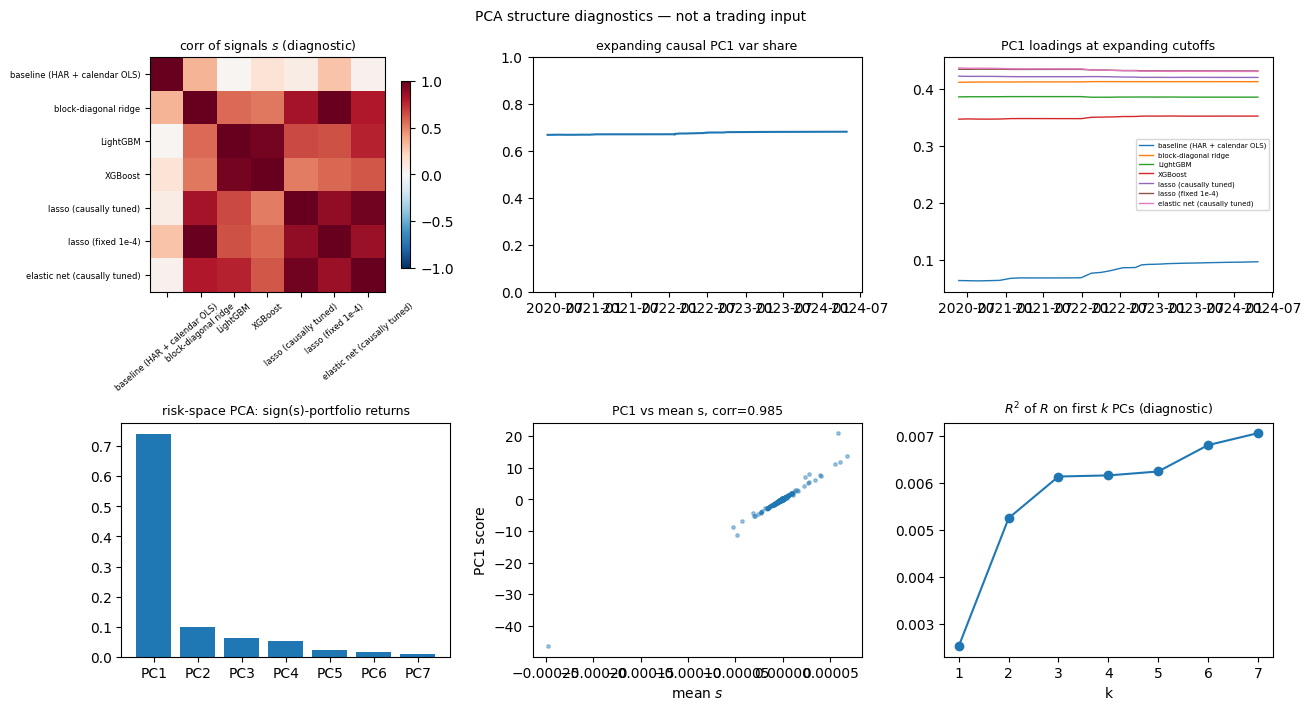

saved pca_lab_structure.png + pca_lab_*.csv


In [6]:
n, p = X.shape
names = [LABEL[t] for t in MODELS]

corr = sig.corr()
agree = pd.DataFrame(
    {ci: {cj: float((pos[ci] == pos[cj]).mean() * 100.0) for cj in MODELS} for ci in MODELS}
).T.loc[MODELS, MODELS]
print("Pearson correlation of daily signals s (diagnostic)")
print(corr.to_string())
print("pairwise sign-agreement % (diagnostic)")
print(agree.to_string())
corr.to_csv(OUT / "pca_lab_sig_corr.csv")
agree.to_csv(OUT / "pca_lab_sign_agree.csv")

# expanding causal PC1 variance share: what a day-t trader would have seen
share_ts = np.full(n, np.nan)
for t in range(63, n):
    past = X[:t]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    s_sing = np.linalg.svd(Xc, compute_uv=False)
    share_ts[t] = float(s_sing[0] ** 2 / (s_sing**2).sum())
share_ts = pd.Series(share_ts, index=sig.index, name="pc1_share")
print("expanding causal PC1 share: first %.4f last %.4f min %.4f max %.4f"
      % (share_ts.dropna().iloc[0], share_ts.dropna().iloc[-1], share_ts.min(), share_ts.max()))
share_ts.to_csv(OUT / "pca_lab_pc1_share_ts.csv")

# PC1 loadings at expanding cutoffs (~monthly), sign aligned to the mean
traj_rows = {}
for c in range(63, n + 1, 21):
    past = X[:c]
    mu, sd = _past_scale(past)
    Xc = (past - mu) / sd
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    traj_rows[sig.index[c - 1]] = v1
traj = pd.DataFrame(traj_rows, index=MODELS).T
print("PC1 loading range over expanding cutoffs")
print(pd.DataFrame({"min": traj.min(), "max": traj.max()}).to_string())
traj.to_csv(OUT / "pca_lab_loadings_traj.csv")

# risk-space PCA: how many independent bets are the sign(s) portfolios?
rets = pos.mul(R, axis=0)
Rc = rets.to_numpy(float)
Rc = Rc - Rc.mean(axis=0)
s_r = np.linalg.svd(Rc, compute_uv=False)
share_risk = pd.Series(s_r**2 / (s_r**2).sum(), index=[f"PC{i+1}" for i in range(p)])
print(f"risk-space PCA variance share ({p} sign(s)-portfolio daily returns, diagnostic)")
print(share_risk.to_string())
share_risk.to_csv(OUT / "pca_lab_riskspace_share.csv")

# full-sample PC1 vs mean s, and the R^2 ladder (correlation scale)
Xc_f = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
_, S_f, Vt_f = np.linalg.svd(Xc_f, full_matrices=False)
if np.dot(Vt_f[0], np.ones(p)) < 0:
    Vt_f = Vt_f.copy()
    Vt_f[0] = -Vt_f[0]
z1 = Xc_f @ Vt_f[0]
mean_s = sig.mean(axis=1).to_numpy()
corr_pc1_mean = float(np.corrcoef(z1, mean_s)[0, 1])
print(f"corr(full-sample PC1 score, mean s) = {corr_pc1_mean:.4f}")

y = R.to_numpy(float)
sst = float(((y - y.mean()) ** 2).sum())
r2 = {}
for k in range(1, p + 1):
    Z1 = np.column_stack([np.ones(n), Xc_f @ Vt_f[:k].T])
    beta, *_ = np.linalg.lstsq(Z1, y, rcond=None)
    r2[k] = 1.0 - float(((y - Z1 @ beta) ** 2).sum()) / sst
r2 = pd.Series(r2, name="R2")
print("full-sample R^2 of daily R on first k PC scores (diagnostic ceiling)")
print(r2.to_string())
r2.to_csv(OUT / "pca_lab_r2_ladder.csv")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))
ax = axes[0, 0]
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(p), names, rotation=40, fontsize=6)
ax.set_yticks(range(p), names, fontsize=6)
ax.set_title("corr of signals $s$ (diagnostic)", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax = axes[0, 1]
ax.plot(share_ts.index, share_ts.to_numpy())
ax.set_title("expanding causal PC1 var share", fontsize=9)
ax.set_ylim(0, 1)
ax = axes[0, 2]
for tag in MODELS:
    ax.plot(traj.index, traj[tag], label=LABEL[tag], lw=1)
ax.set_title("PC1 loadings at expanding cutoffs", fontsize=9)
ax.legend(fontsize=5)
ax = axes[1, 0]
ax.bar(share_risk.index, share_risk.to_numpy())
ax.set_title("risk-space PCA: sign(s)-portfolio returns", fontsize=9)
ax = axes[1, 1]
ax.scatter(mean_s, z1, s=6, alpha=0.4)
ax.set_xlabel("mean $s$")
ax.set_ylabel("PC1 score")
ax.set_title(f"PC1 vs mean s, corr={corr_pc1_mean:.3f}", fontsize=9)
ax = axes[1, 2]
ax.plot(r2.index, r2.to_numpy(), marker="o")
ax.set_xlabel("k")
ax.set_title("$R^2$ of $R$ on first $k$ PCs (diagnostic)", fontsize=9)
fig.suptitle("PCA structure diagnostics — not a trading input", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "pca_lab_structure.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved pca_lab_structure.png + pca_lab_*.csv")


## 6. Vol-space maps

Stand-in for `atm_straddle_volmap.ipynb`: $\hat y\sqrt{B}$ and
$m\sqrt{B}$ against $\mathrm{IV}_{30}$ and $\sqrt{\mathrm{rv\_raw}}$.

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\volmap_a0_blk2.png


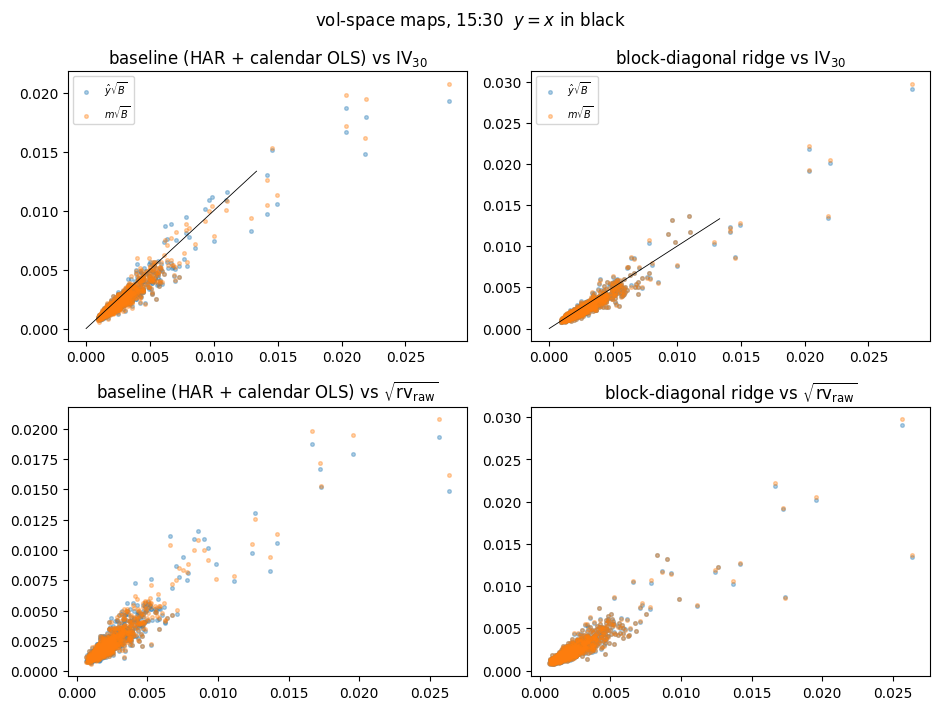

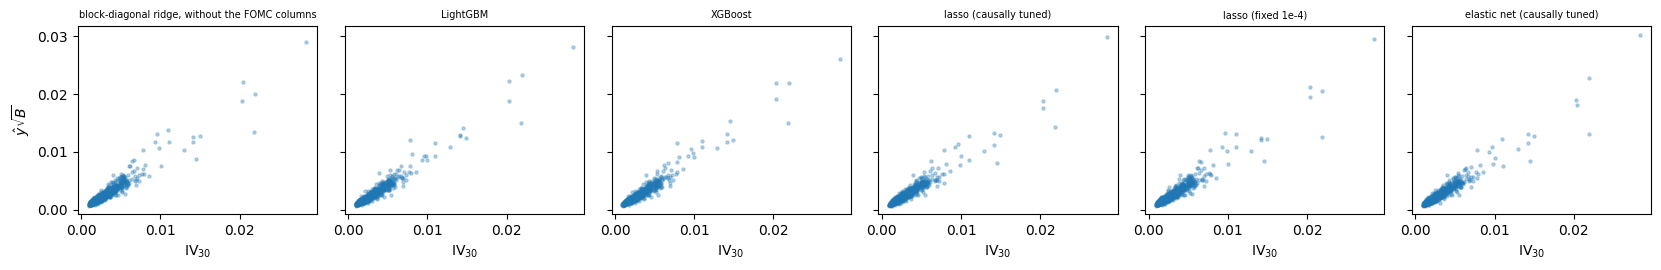

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.2))
for col, tag in enumerate(("a0", "blk2")):
    px = books[tag].loc[common]
    axes[0, col].scatter(px["iv_30"], px["yhat_vol"], s=7, alpha=0.35, label=r"$\hat y\sqrt{B}$")
    axes[0, col].scatter(px["iv_30"], px["m_vol"], s=7, alpha=0.35, label=r"$m\sqrt{B}$")
    axes[0, col].set_title(LABEL[tag] + r" vs $\mathrm{IV}_{30}$")
    axes[0, col].legend(fontsize=7)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["yhat_vol"], s=7, alpha=0.35)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["m_vol"], s=7, alpha=0.35)
    axes[1, col].set_title(LABEL[tag] + r" vs $\sqrt{\mathrm{rv_{raw}}}$")
    lo, hi = 0, float(np.nanpercentile(px["iv_30"], 99))
    axes[0, col].plot([lo, hi], [lo, hi], color="k", lw=0.6)
fig.suptitle(r"vol-space maps, 15:30  $y=x$ in black")
fig.tight_layout()
fig.savefig(OUT / "volmap_a0_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "volmap_a0_blk2.png")
display(fig)
plt.close(fig)

rest = [t for t in MODEL_ORDER if t not in ("a0", "blk2")]
fig, axes = plt.subplots(1, len(rest), figsize=(2.8 * len(rest), 2.8), sharey=True)
for ax, tag in zip(np.atleast_1d(axes), rest):
    px = books[tag].loc[common]
    ax.scatter(px["iv_30"], px["yhat_vol"], s=5, alpha=0.3)
    ax.set_title(LABEL[tag], fontsize=7)
    ax.set_xlabel(r"$\mathrm{IV}_{30}$")
np.atleast_1d(axes)[0].set_ylabel(r"$\hat y\sqrt{B}$")
fig.tight_layout()
fig.savefig(OUT / "volmap_yhat_vs_iv_rest.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 7. Other well-motivated weighting strategies

Two magnitude-based sizes remain: the expanding percentile rank of
$|s|$ (size $1+4(\text{rank}-\tfrac12)$, clipped to $[0,3]$) and the
inverse of the expanding volatility of $R$, normalised by the lagged
expanding median of that volatility and capped at 3. The dead-zone rule
(a threshold on the expanding median of $|s|$) and the Kelly-style
$s/\widehat{\mathrm{Var}}(R)$ were removed: the first is the banned
median scaling, the second divides a variance-unit signal by a
return-unit variance and sizes nothing. Scored on the common days;
block-diagonal ridge shown; CSVs for every model.

In [8]:
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = asl.extra_weight_sizes(px)
    extra_names = list(sizes)
    sizes.update(asl.rule_sizes(px))
    tab = pd.DataFrame({
        name: asl.rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in extra_names + ["sign(s)", "always short"]
    }).T
    tab.to_csv(OUT / f"experimental_weights_{tag}.csv")
    if tag == "blk2":
        print("blk2 extra weights")
        print(tab.to_string())
print("saved experimental_weights_*.csv")


blk2 extra weights
                       n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
rank-|s|      866.000000  0.070448  1.040847  -8.365690 -0.170974  0.000000  0.387309   6.836034 -0.190651  10.872813  1.991764    1.074433  214.000000  24.711316
inv-vol of R  866.000000  0.096674  1.135687  -5.475820 -0.707852  0.131696  0.865727  10.506060  0.928053  10.872203  2.505022    1.351304  346.000000  39.953811
sign(s)       866.000000  0.094736  1.123716  -5.422480 -0.717045  0.129832  0.869517  10.316049  0.917037  10.612224  2.480957    1.338322  346.000000  39.953811
always short  866.000000  0.014475  1.127614 -10.316049 -0.448603  0.327356  0.928103   1.000000 -2.311621  10.891894  0.377762    0.203779    0.000000   0.000000


saved experimental_weights_*.csv


## 8. Iron condor lab: width ladder

Body is the §1 nearest-OTM package; wings are the nearest live 15:30
mids at least $w$ points further OTM (`asl.pick_wings`; the same wing
selection as the defined-risk portfolio parked in the RV–IV deck and explored in §14 here). Short
iron condor = short body + long wings.
Defined-risk long-package return is
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged; the two rules use the blk2
signal. Credit-denominator $R$ stays a warning only
(`frac_entry_ic_le0` is the fraction of the scored common days with net
credit $\le 0$).

Two width families:

- *fixed:* $w\in\{10,25,50,75,100\}$ points.
- *vol-scaled:* $w = c\cdot\mathrm{entry}_{\mathrm{body}}$,
  $c\in\{1,2,4\}$. The package price is the natural vol-dollar unit
  (it is the market's expected move to the close), so wings sit at a
  roughly constant moneyness-in-vol instead of a constant point
  distance. Bounded by construction: $\mathrm{entry}>0$ on every
  scored day. The realized width snaps up to the strike grid;
  `med_eff_width` reports the median realized width.

Coverage at these widths is full — the per-width line printed by the
cell reports zero body days without both wings — so every row is scored
on the same blk2 `common` days. A wider ladder would start dropping exactly the
high-vol days — re-check coverage before extending it.

Columns: `n` days scored; `mean`/`std` of $R'=q\,R_{\mathrm{long,ic}}$;
`t_mean` $=\bar R'/\mathrm{sd}\times\sqrt{n}$; `Sharpe_ann`
$=\bar R'/\mathrm{sd}\times\sqrt{252}$ (one package per day, daily
annualization is correct here); `pct_buy` per cent of days with
$q>0$; `med_credit` median $\mathrm{entry}_{ic}$.

w10: days with both wings 1279 / body 1279 dropped 0


w25: days with both wings 1279 / body 1279 dropped 0


w50: days with both wings 1279 / body 1279 dropped 0


w75: days with both wings 1279 / body 1279 dropped 0


w100: days with both wings 1279 / body 1279 dropped 0


c1xentry: days with both wings 1279 / body 1279 dropped 0


c2xentry: days with both wings 1279 / body 1279 dropped 0


c4xentry: days with both wings 1279 / body 1279 dropped 0


--- condor width ladder, defined-risk R, blk2, common days ---
                                n      mean       std    t_mean  Sharpe_ann    pct_buy  med_eff_width  med_credit  frac_entry_ic_le0
width    rule                                                                                                                       
w10      always short  866.000000 -0.004939  0.359439 -0.404379   -0.218138   0.000000      10.000000    4.325000           0.000000
         sign(s)       866.000000  0.022256  0.358782  1.825494    0.984740  39.953811      10.000000    4.325000           0.000000
w25      always short  866.000000  0.001056  0.238049  0.130508    0.070401   0.000000      25.000000    5.200000           0.000000
         sign(s)       866.000000  0.012829  0.237705  1.588229    0.856751  39.953811      25.000000    5.200000           0.000000
w50      always short  866.000000  0.000970  0.141347  0.202009    0.108971   0.000000      50.000000    5.300000           0.000000
      

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_width_ladder.png


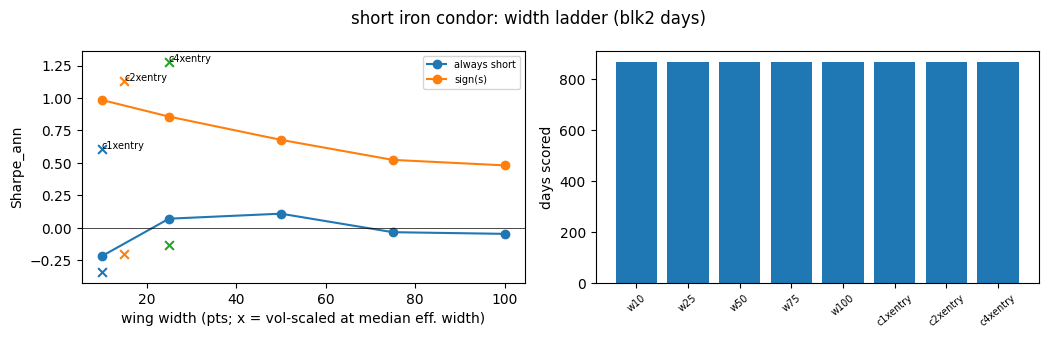

In [9]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def pick_wings_perday(live_q: pd.DataFrame, body_df: pd.DataFrame, w_row) -> pd.DataFrame:
    # asl.pick_wings with a per-day width; w_row is aligned to body_df rows.
    c = live_q[live_q["cp"] == "C"].copy()
    p = live_q[live_q["cp"] == "P"].copy()
    want_c = body_df[["expiration", "K_c"]].copy()
    want_p = body_df[["expiration", "K_p"]].copy()
    want_c["w"] = np.asarray(w_row, float)
    want_p["w"] = np.asarray(w_row, float)
    c = c.merge(want_c, on="expiration", how="inner")
    p = p.merge(want_p, on="expiration", how="inner")
    c = c[c["strike"].astype(float) >= (c["K_c"] + c["w"])]
    p = p[p["strike"].astype(float) <= (p["K_p"] - p["w"])]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c_w = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p_w = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    wings = c_w.merge(p_w, on="expiration", suffixes=("_cw", "_pw"))
    wing_cols = ["expiration", "strike_cw", "strike_pw", "mid_cw", "mid_pw"]
    extra = [col for col in ("bid_cw", "ask_cw", "bid_pw", "ask_pw") if col in wings.columns]
    out = body_df.merge(wings[wing_cols + extra], on="expiration", how="inner")
    out["K_c_wing"] = out["strike_cw"].astype(float)
    out["K_p_wing"] = out["strike_pw"].astype(float)
    out["mid_c_wing"] = out["mid_cw"].astype(float)
    out["mid_p_wing"] = out["mid_pw"].astype(float)
    out["entry_body"] = out["entry"].astype(float)
    out["entry_wings"] = out["mid_c_wing"] + out["mid_p_wing"]
    out["entry_ic"] = out["entry_body"] - out["entry_wings"]
    out["width"] = np.minimum(out["K_c_wing"] - out["K_c"], out["K_p"] - out["K_p_wing"])
    return out

def settle_ic(ic_raw: pd.DataFrame, label: str) -> pd.DataFrame:
    print(f"{label}: days with both wings {len(ic_raw)} / body {len(body)} dropped {len(body) - len(ic_raw)}")
    ic = asl.settle_package(ic_raw, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["R_credit"] = np.where(ic["entry_ic"] > 0, ic["exit_ic"] / ic["entry_ic"] - 1.0, np.nan)
    return ic.set_index("day")

ladder = {}
for w in (10.0, 25.0, 50.0, 75.0, 100.0):
    ladder[f"w{int(w)}"] = settle_ic(asl.pick_wings(live, body, width=w), f"w{int(w)}")
for cmult in (1.0, 2.0, 4.0):
    ladder[f"c{int(cmult)}xentry"] = settle_ic(
        pick_wings_perday(live, body, cmult * body["entry"].to_numpy(float)), f"c{int(cmult)}xentry"
    )

rows = []
grid = {}
for label, ic in ladder.items():
    joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    common_ic = joined.index.intersection(common)
    grid[label] = {}
    for name in asl.RULE_ORDER:
        rr = asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic], sizes[name].loc[common_ic])
        rows.append({
            "width": label, "rule": name, "n": rr["n"], "mean": rr["mean"], "std": rr["std"],
            "t_mean": rr["t_mean"], "Sharpe_ann": rr["Sharpe_ann"], "pct_buy": rr["pct_buy"],
            "med_eff_width": float(joined.loc[common_ic, "width"].median()),
            "med_credit": float(joined.loc[common_ic, "entry_ic"].median()),
            "frac_entry_ic_le0": float((ic.loc[common_ic, "entry_ic"] <= 0).mean()),
        })
        grid[label][name] = rr["Sharpe_ann"]

lad_tab = pd.DataFrame(rows).set_index(["width", "rule"])
grid_tab = pd.DataFrame(grid).T[asl.RULE_ORDER]
print("--- condor width ladder, defined-risk R, blk2, common days ---")
print(lad_tab.to_string())
print("--- Sharpe_ann grid ---")
print(grid_tab.to_string())
bench = asl.rule_row((-books["blk2"]["R"]).loc[common], pd.Series(-1.0, index=common))
print(f"benchmark always-short STRADDLE (same days): mean {bench['mean']:.4f} "
      f"t {bench['t_mean']:.2f} Sharpe_ann {bench['Sharpe_ann']:.3f}")
lad_tab.to_csv(OUT / "condor_lab_ladder_blk2.csv")
grid_tab.to_csv(OUT / "condor_lab_sharpe_grid_blk2.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
fixed = [lb for lb in grid_tab.index if lb.startswith("w")]
xs = [float(lb[1:]) for lb in fixed]
for name in asl.RULE_ORDER:
    axes[0].plot(xs, [grid_tab.loc[lb, name] for lb in fixed], marker="o", label=name)
for lb in [x for x in grid_tab.index if x.startswith("c")]:
    mw = lad_tab.xs(lb, level="width")["med_eff_width"].iloc[0]
    axes[0].scatter([mw] * len(asl.RULE_ORDER), grid_tab.loc[lb].to_numpy(), marker="x", s=40)
    axes[0].annotate(lb, (mw, float(grid_tab.loc[lb].max())), fontsize=7)
axes[0].set_xlabel("wing width (pts; x = vol-scaled at median eff. width)")
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
axes[0].axhline(0.0, color="k", lw=0.5)
ns = lad_tab.xs("always short", level="rule")["n"]
axes[1].bar(range(len(ns)), ns.to_numpy())
axes[1].set_xticks(range(len(ns)), ns.index, rotation=40, fontsize=7)
axes[1].set_ylabel("days scored")
fig.suptitle("short iron condor: width ladder (blk2 days)")
fig.tight_layout()
fig.savefig(OUT / "condor_lab_width_ladder.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_width_ladder.png")
display(fig)
plt.close(fig)


## 9. Iron condor diagnostics (w=25, 50)

Body is the 15:30 nearest-OTM package; wings are the nearest live mids
at least $25$ (and $50$) points further OTM, as in the RV–IV notebook.
Defined-risk return $R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$.
Four diagnostics, all on blk2 common days:

1. **Wing-cost share** $\mathrm{entry}_{\mathrm{wings}}/\mathrm{entry}_{\mathrm{body}}$
   by year and by $\mathrm{IV}_{30}$ quintile. This is what the tail
   insurance costs, and when.
2. **Coverage**: days with both wings vs body days.
3. **Tail tables**: worst 10 days by straddle $\mathrm{sign}(s)$ $R'$ with the
   condor $\mathrm{sign}(s)$ $R'$ beside them, and the reverse. The condor
   loss is capped by construction, but the cap is not one expression:
   the denominator is $\mathrm{width}=\min(\mathrm{gap}_c,\mathrm{gap}_p)$
   while the seller's worst case runs to the larger actual gap, so a sold
   condor is floored at
   $-(\mathrm{gap}_{\max}-\mathrm{entry}_{ic})/\mathrm{width}$ and a
   bought one at $-\mathrm{entry}_{ic}/\mathrm{width}$, the debit paid.
   Either way better tails are **mechanical** (defined risk), not alpha.
4. **IR** of condor $\mathrm{sign}(s)$ against the straddle always-short and
   straddle $\mathrm{sign}(s)$ portfolios: active $R^a=R^{ic}-R^{\mathrm{bench}}$,
   `te_daily` $=\mathrm{sd}(R^a)$, $\mathrm{IR}_{ann}=\bar R^a/\mathrm{sd}\times\sqrt{252}$,
   $t=\bar R^a/\mathrm{sd}\times\sqrt{n}$.

Condor and straddle positions are the $\mathrm{sign}(s)$ rule at
$|q|=1$ (and always short). Cumulative $R'$ is a non-compounded sum.

In [10]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def build_condor(width: float) -> pd.DataFrame:
    ic = asl.pick_wings(live, body, width=width)
    n_body, n_ic = len(body), len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["wing_share"] = ic["entry_wings"] / ic["entry_body"]
    ic["day"] = pd.to_datetime(ic["et_c"]).dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
    ic = ic.set_index("day").sort_index()
    print(f"width {width}: days with both wings {n_ic} / body {n_body} dropped {n_body - n_ic}")
    return ic

ics = {w: build_condor(w) for w in (25.0, 50.0)}
# every diagnostic below runs on the scored (common) days, not on the whole wing frame
ics_c = {w: ic.loc[ic.index.intersection(common)] for w, ic in ics.items()}

cov = pd.DataFrame({
    f"w{int(w)}": {"days_with_wings": len(ic), "body_days": len(body), "dropped": len(body) - len(ic),
                   "common_days": len(common), "common_days_with_wings": len(ics_c[w])}
    for w, ic in ics.items()
}).T
print("coverage")
print(cov.to_string())
cov.to_csv(OUT / "condor_lab_diag_coverage.csv")

share_tabs = {}
for w, ic in ics_c.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    q5 = pd.qcut(ic["iv_30"], 5, labels=[f"Q{i}" for i in range(1, 6)])
    by_iv = ic["wing_share"].groupby(q5, observed=True).median()
    share_tabs[f"w{int(w)}_year"] = by_year
    share_tabs[f"w{int(w)}_iv30q"] = by_iv
    print(f"wing-cost share entry_wings/entry_body, width {int(w)}: median {float(ic['wing_share'].median()):.4f} ({len(ic)} common days)")
    print("by year"); print(by_year.to_string())
    print("by IV30 quintile"); print(by_iv.to_string())
pd.DataFrame(share_tabs).to_csv(OUT / "condor_lab_diag_wingshare.csv")

blk = books["blk2"]
strad_sizes = asl.rule_sizes(blk)
strad_sg = (strad_sizes["sign(s)"] * blk["R"]).loc[common]
strad_as = (-blk["R"]).loc[common]

cond_sg = {}
for w, ic in ics.items():
    joined = ic.join(blk[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    idx = joined.index.intersection(common)
    cond_sg[w] = (sizes["sign(s)"] * joined["R_long_ic"]).loc[idx]

ir_rows = {}
for w in ics:
    ir_rows[f"IC-sign(s) w{int(w)} vs straddle AS"] = asl.information_ratio(cond_sg[w], strad_as)
    ir_rows[f"IC-sign(s) w{int(w)} vs straddle sign(s)"] = asl.information_ratio(cond_sg[w], strad_sg)
ir_tab = pd.DataFrame(ir_rows).T
print("IR of condor sign(s) vs straddle benchmarks")
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "condor_lab_diag_ir.csv")

joint = strad_sg.index.intersection(cond_sg[25.0].index).intersection(cond_sg[50.0].index)
tails = pd.DataFrame({
    "straddle sign(s)": strad_sg.loc[joint],
    "IC-sign(s) w25": cond_sg[25.0].loc[joint],
    "IC-sign(s) w50": cond_sg[50.0].loc[joint],
})
worst_strad = tails.nsmallest(10, "straddle sign(s)")
worst_ic25 = tails.nsmallest(10, "IC-sign(s) w25")
print("worst 10 days by straddle sign(s) R'")
print(worst_strad.to_string())
print("worst 10 days by IC-sign(s) w25 R'")
print(worst_ic25.to_string())
worst_strad.to_csv(OUT / "condor_lab_diag_tails_straddle.csv")
worst_ic25.to_csv(OUT / "condor_lab_diag_tails_ic25.csv")


width 25.0: days with both wings 1279 / body 1279 dropped 0


width 50.0: days with both wings 1279 / body 1279 dropped 0
coverage
     days_with_wings  body_days  dropped  common_days  common_days_with_wings
w25             1279       1279        0          866                     866
w50             1279       1279        0          866                     866
wing-cost share entry_wings/entry_body, width 25: median 0.0367 (866 common days)
by year
2020    0.043614
2021    0.034935
2022    0.053797
2023    0.030303
2024    0.039474
by IV30 quintile
iv_30
Q1    0.030303
Q2    0.029268
Q3    0.032710
Q4    0.042105
Q5    0.111354
wing-cost share entry_wings/entry_body, width 50: median 0.0133 (866 common days)
by year
2020    0.013590
2021    0.016949
2022    0.010152
2023    0.013423
2024    0.014085
by IV30 quintile
iv_30
Q1    0.018868
Q2    0.013158
Q3    0.010309
Q4    0.009174
Q5    0.015411
IR of condor sign(s) vs straddle benchmarks
                                             n  mean_active  te_daily     te_ann    IR_ann  t_active      t

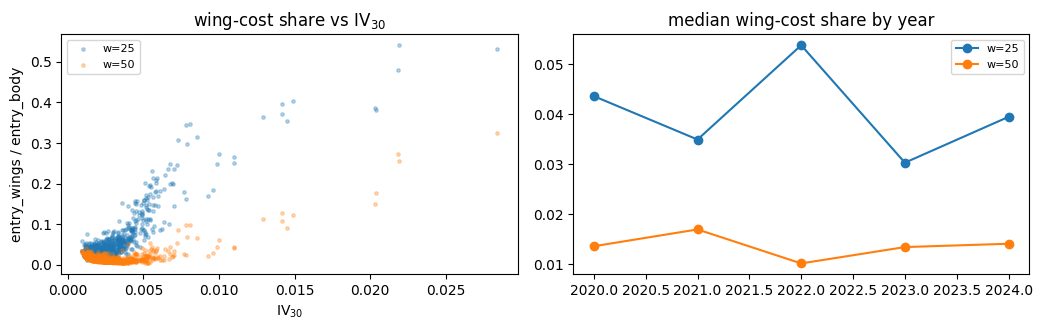

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_cum.png


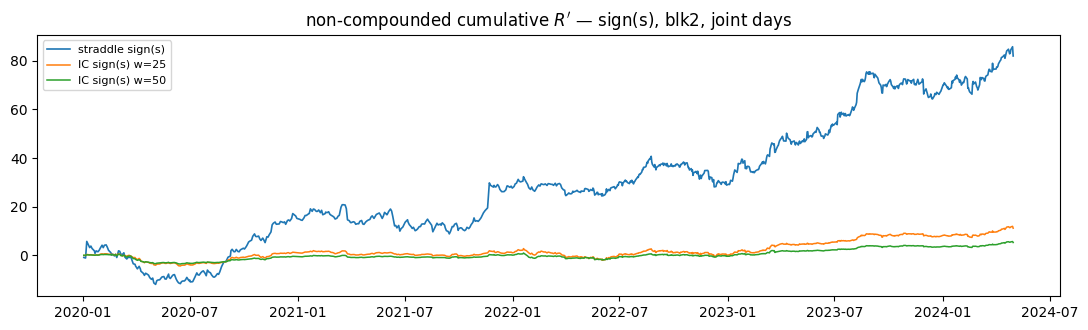

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for w, ic in ics_c.items():
    axes[0].scatter(ic["iv_30"], ic["wing_share"], s=6, alpha=0.3, label=f"w={int(w)}")
axes[0].set_xlabel(r"$\mathrm{IV}_{30}$")
axes[0].set_ylabel("entry_wings / entry_body")
axes[0].set_title("wing-cost share vs $\\mathrm{IV}_{30}$")
axes[0].legend(fontsize=8)
for w, ic in ics_c.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    axes[1].plot(by_year.index, by_year.values, marker="o", label=f"w={int(w)}")
axes[1].set_title("median wing-cost share by year")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_diagnostics.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(joint, strad_sg.loc[joint].cumsum().values, label="straddle sign(s)", lw=1.2)
for w in ics:
    ax.plot(joint, cond_sg[w].loc[joint].cumsum().values, label=f"IC sign(s) w={int(w)}", lw=1.1)
ax.set_title("non-compounded cumulative $R'$ — sign(s), blk2, joint days")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_cum.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_cum.png")
display(fig)
plt.close(fig)


## 10. Strangle-body condors and per-side attribution

The defined-risk portfolio (parked in the RV–IV deck, explored in §14) wraps the straddle-body
package in wings. Here the body is a **strangle**: the next listed strike above the
nearest-OTM call and below the nearest-OTM put, from the same 15:30
live mids (one step on the actual grid — $5$ points on $99.6\%$ of
days, never a fixed offset). Wings are `asl.pick_wings` measured from
the strangle legs, widths $25$ and $50$. Defined-risk return is
unchanged,
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply as-is; blk2 signal, common days.

**Per-side split** ($w=25$, $\mathrm{sign}(s)$ $q$). Each side is its own
vertical: $R_{\mathrm{call}}=\big[(\mathrm{pay}_c-\mathrm{pay}_{cw})-(\mathrm{mid}_c-\mathrm{mid}_{cw})\big]/\mathrm{width}$,
same for the put side, so
$R_{\mathrm{call}}+R_{\mathrm{put}}=R_{\mathrm{long,ic}}$ exactly
(same denominator). $R'_{\mathrm{side}}=q\,R_{\mathrm{side}}$ answers
two questions: which spread earns the short-portfolio mean, and which
spread bleeds on the worst-decile days. The worst-decile rows are
descriptive — the subsample is selected on the outcome — so no $t$ is
reported for them.

In [12]:
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
body_straddle = atm.reset_index()

def pick_strangle_body(live, atm_body):
    c = live[live["cp"] == "C"].copy()
    p = live[live["cp"] == "P"].copy()
    want = atm_body[["expiration", "day", "K_c", "K_p", "S"]].copy()
    c = c.merge(want[["expiration", "K_c"]], on="expiration", how="inner")
    p = p.merge(want[["expiration", "K_p"]], on="expiration", how="inner")
    c = c[c["strike"].astype(float) > c["K_c"]]
    p = p[p["strike"].astype(float) < p["K_p"]]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c2 = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p2 = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    legs = c2.merge(p2, on="expiration", suffixes=("_c", "_p"))
    out = want.merge(legs[["expiration", "strike_c", "strike_p", "mid_c", "mid_p"]],
                     on="expiration", how="inner", suffixes=("_atm", ""))
    out = out.rename(columns={"K_c": "K_c_atm", "K_p": "K_p_atm"})
    out["K_c"] = out["strike_c"].astype(float)
    out["K_p"] = out["strike_p"].astype(float)
    out["entry"] = out["mid_c"].astype(float) + out["mid_p"].astype(float)
    out["step_c"] = out["K_c"] - out["K_c_atm"]
    out["step_p"] = out["K_p_atm"] - out["K_p"]
    return out

body_strangle = pick_strangle_body(live, body_straddle)
print(f"strangle legs {len(body_strangle)} / body {len(body_straddle)}; "
      f"call step 5 on {float((body_strangle['step_c'] == 5).mean()):.1%} of days")

def score_ic(body, width, label):
    ic = asl.pick_wings(live, body, width=width)
    print(f"{label} width {width}: days with both wings {len(ic)} / body {len(body)}")
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    return ic.set_index("day").sort_index()

RULES = ["always short", "sign(s)"]
KEEP = ["n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
sg_tabs, sg_frames = {}, {}
for label, body in (("straddle", body_straddle), ("strangle", body_strangle)):
    for w in (25.0, 50.0):
        ic = score_ic(body, w, label)
        joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
        sizes = asl.rule_sizes(joined)
        common_ic = joined.index.intersection(common)
        tab = pd.DataFrame({
            name: asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic],
                               sizes[name].loc[common_ic])
            for name in RULES
        }).T
        sg_tabs[(label, int(w))] = tab
        sg_frames[(label, int(w))] = (joined, sizes, common_ic)
        tab.to_csv(OUT / f"condor_lab_strangle_rules_{label}_w{int(w)}.csv")
for w in (25, 50):
    print(f"--- defined-risk R, blk2, width {w}: straddle vs strangle body ---")
    print(pd.concat({lb: sg_tabs[(lb, w)][KEEP] for lb in ("straddle", "strangle")},
                    names=["body", "rule"]).to_string())


strangle legs 1279 / body 1279; call step 5 on 99.6% of days


straddle width 25.0: days with both wings 1279 / body 1279


straddle width 50.0: days with both wings 1279 / body 1279


strangle width 25.0: days with both wings 1279 / body 1279


strangle width 50.0: days with both wings 1279 / body 1279
--- defined-risk R, blk2, width 25: straddle vs strangle body ---
                                n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                                                               
straddle always short  866.000000  0.001056  0.130508    0.070401   0.000000
         sign(s)       866.000000  0.012829  1.588229    0.856751  39.953811
strangle always short  866.000000  0.005039  0.727865    0.392638   0.000000
         sign(s)       866.000000  0.010285  1.487096    0.802196  39.953811
--- defined-risk R, blk2, width 50: straddle vs strangle body ---
                                n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                                                               
straddle always short  866.000000  0.000970  0.202009    0.108971   0.000000
         sign(s)       866.000000  0.006029  1.256274    0.677682  39.953811
strangle always short  866.000000  0.00

per-side attribution, w=25, sign(s) R'
                                                   n      mean         t  share_of_total
body     side scope                                                                     
straddle call all                         866.000000  0.003329  0.460747        0.259517
              worst-decile (descriptive)   87.000000 -0.210483       NaN        0.484426
         put  all                         866.000000  0.009500  1.257208        0.740483
              worst-decile (descriptive)   87.000000 -0.224016       NaN        0.515574
strangle call all                         866.000000  0.003375  0.605052        0.328099
              worst-decile (descriptive)   87.000000 -0.190430       NaN        0.474010
         put  all                         866.000000  0.006911  1.164450        0.671901
              worst-decile (descriptive)   87.000000 -0.211313       NaN        0.525990


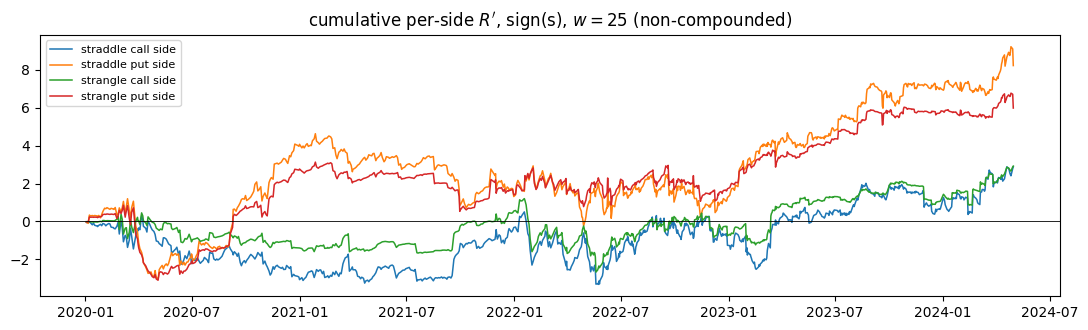

In [13]:
side_rows, side_cum = {}, {}
for label in ("straddle", "strangle"):
    joined, sizes, common_ic = sg_frames[(label, 25)]
    j = joined.loc[common_ic].copy()
    q = sizes["sign(s)"].loc[common_ic]
    j["R_call"] = ((j["pay_c"] - j["pay_c_wing"]) - (j["mid_c"].astype(float) - j["mid_c_wing"])) / j["width"]
    j["R_put"] = ((j["pay_p"] - j["pay_p_wing"]) - (j["mid_p"].astype(float) - j["mid_p_wing"])) / j["width"]
    assert (j["R_call"] + j["R_put"] - j["R_long_ic"]).abs().max() < 1e-10
    rp_tot = q * j["R_long_ic"]
    worst = rp_tot <= rp_tot.quantile(0.10)
    for side in ("R_call", "R_put"):
        rp = q * j[side]
        side_cum[(label, side)] = rp.cumsum()
        for scope, mask in (("all", rp_tot.notna()), ("worst-decile (descriptive)", worst)):
            x = rp[mask]
            mu, sd, n = float(x.mean()), float(x.std(ddof=1)), int(len(x))
            # the worst-decile rows select the subsample on the outcome, so no t is reported there
            side_rows[(label, side.replace("R_", ""), scope)] = {
                "n": n, "mean": mu,
                "t": (mu / sd * np.sqrt(n) if sd > 0 else np.nan) if scope == "all" else np.nan,
                "share_of_total": mu / float(rp_tot[mask].mean()),
            }
side_tab = pd.DataFrame(side_rows).T
side_tab.index.names = ["body", "side", "scope"]
print("per-side attribution, w=25, sign(s) R'")
print(side_tab.to_string())
side_tab.to_csv(OUT / "condor_lab_strangle_per_side_w25.csv")

fig, ax = plt.subplots(figsize=(11, 3.4))
for (label, side), cum in side_cum.items():
    ax.plot(cum.index, cum.values, lw=1.1,
            label=f"{label} {side.replace('R_', '')} side")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("cumulative per-side $R'$, sign(s), $w=25$ (non-compounded)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_strangle.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 11. Ensembles on the iron condor (defined-risk $R$)

One question: do the §5 ensemble positions transfer from the straddle
to the defined-risk condor instrument? The positions $q_t$ (mean-$s$
sign, majority vote, EW $\mathrm{sign}(s)$ $q$, causal spectral PC1
sign, and the blk2 single-model benchmarks) are built once on
the common days exactly as in §5 and are not refit. Only the
instrument swaps: wings are the nearest live mids at least $w$ points
further OTM ($w=25,50$; the same wing selection as the credit-vertical
construction of §14) and
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged.

Each width prints two tables on the same day set $D_w$ (common days
with both wings): the condor portfolio, and the same $q$ on the straddle
$R$. The mirror isolates instrument transfer from day-set drift; with
full wing coverage $D_w$ equals the common days and the drift is zero.

Caveats. Defined-risk $R$ divides by width, not premium: losses are
capped by construction and the denominator differs across instruments,
so Sharpe moves are partly tail/denominator effects, not signal
quality. The defined-risk portfolio, parked in the RV–IV deck, is scored per
body premium at $|q|=1$, so its rows are not in the same units as
these tables.

In [14]:
qs = {
    "mean-s then sign": np.sign(sig.mean(axis=1)).replace(0.0, -1.0),
    "majority vote": np.sign(pos.sum(axis=1)).replace(0.0, -1.0),
    "EW sign(s) q": pos.mean(axis=1),
    "spectral PC1 sign": q_pc1,
    "blk2 sign(s)": blk_sizes["sign(s)"].loc[common],
    "blk2 always short": pd.Series(-1.0, index=common),
}
body = atm.reset_index()
_exp = pd.to_datetime(atm["expiration"])
if getattr(_exp.dt, "tz", None) is not None:
    _exp = _exp.dt.tz_convert("America/New_York").dt.tz_localize(None)
close_map = pd.Series(atm["S_close"].to_numpy(), index=_exp.dt.normalize().values)

def bridge_table(r, D):
    return pd.DataFrame(
        {name: asl.rule_row(q.loc[D] * r.loc[D], q.loc[D]) for name, q in qs.items()}
    ).T

SHOW = ["n", "mean", "std", "t_mean", "Sharpe_ann", "pct_buy"]
tabs = {}
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, body, width=w)
    n_wings = len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic = ic.set_index("day")
    D = ic.index.intersection(common)
    print(f"width {int(w)}: both wings {n_wings} / {len(body)} body days; "
          f"scored D = common & coverage = {len(D)} / {len(common)} common")
    print(f"width {int(w)} frac entry_ic<=0 on the scored days = {float((ic.loc[D, 'entry_ic'] <= 0).mean()):.2%}")
    tabs[(int(w), "condor")] = bridge_table(ic["R_long_ic"], D)
    tabs[(int(w), "straddle same days")] = bridge_table(R, D)
    print(f"--- ensembles on iron condor w={int(w)}, defined-risk R ---")
    print(tabs[(int(w), "condor")][SHOW].to_string())
    print(f"--- same q on straddle R, same {len(D)} days ---")
    print(tabs[(int(w), "straddle same days")][SHOW].to_string())
pd.concat(tabs, names=["width", "instrument", "rule"]).to_csv(OUT / "condor_lab_ensemble.csv")
print("saved", OUT / "condor_lab_ensemble.csv")


width 25: both wings 1279 / 1279 body days; scored D = common & coverage = 866 / 866 common
width 25 frac entry_ic<=0 on the scored days = 0.00%
--- ensembles on iron condor w=25, defined-risk R ---
                            n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign   866.000000  0.015882  0.237520  1.967684    1.061443  36.143187
majority vote      866.000000  0.012971  0.237697  1.605837    0.866249  36.836028
EW sign(s) q       866.000000  0.013186  0.208222  1.863582    1.005286  36.836028
spectral PC1 sign  866.000000  0.004472  0.238009  0.552886    0.298248  58.429561
blk2 sign(s)       866.000000  0.012829  0.237705  1.588229    0.856751  39.953811
blk2 always short  866.000000  0.001056  0.238049  0.130508    0.070401   0.000000
--- same q on straddle R, same 866 days ---
                            n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign   866.000000  0.105035  1.122799  2.752914    1.485025  36.143187
majority v

width 50: both wings 1279 / 1279 body days; scored D = common & coverage = 866 / 866 common
width 50 frac entry_ic<=0 on the scored days = 0.00%
--- ensembles on iron condor w=50, defined-risk R ---
                            n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign   866.000000  0.009369  0.141039  1.954787    1.054486  36.143187
majority vote      866.000000  0.007314  0.141161  1.524747    0.822506  36.836028
EW sign(s) q       866.000000  0.008054  0.121948  1.943587    1.048444  36.836028
spectral PC1 sign  866.000000  0.002604  0.141327  0.542154    0.292458  58.429561
blk2 sign(s)       866.000000  0.006029  0.141222  1.256274    0.677682  39.953811
blk2 always short  866.000000  0.000970  0.141347  0.202009    0.108971   0.000000
--- same q on straddle R, same 866 days ---
                            n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign   866.000000  0.105035  1.122799  2.752914    1.485025  36.143187
majority v

## 12. Fill sensitivity (quoted-spread $\lambda$-fills)

A condor has four legs, a straddle two: quoted-spread cost is the
standing objection to any condor result. Fill model, per leg,

$$\mathrm{fill} = \mathrm{mid} + \sigma\,\lambda\,\tfrac{\mathrm{ask}-\mathrm{bid}}{2},
\qquad \sigma=+1\ \text{bought},\ \sigma=-1\ \text{sold},\qquad
\lambda\in\{0,\tfrac12,1\}.$$

$\lambda=0$ is the mid-fill portfolio; $\lambda=1$ fills every short leg at
the bid and every long leg at the ask (the lib's
`crossed_premium_return` at the straddle). Exit is cash settlement at
the official close — no exit spread. The signal $s$ is untouched:
fills change $R$, not $s$, so positions are identical across
$\lambda$ and the tables isolate pure fill cost. Straddle $R$ keeps
the entry denominator (now the filled entry); condor $R$ keeps the
width denominator, so its cost enters linearly:
$R'=qR_{\mathrm{long,ic}} - |q|\,\lambda\,H/\mathrm{width}$ with $H$
the sum of the four half-spreads.

Quote hygiene: sold legs require $\mathrm{bid}>0$; bought wing legs
allow a zero bid (a legitimate deep-OTM quote state — the buy fills at
the ask side). Zero-bid wings are the norm, not the exception — the
hygiene lines below count them at every width — which is exactly why
wing spreads are proportionally enormous while body spreads are tight.
The scored set is the quoted subset of the common days; the cell prints
both counts. Once the half sessions are out of the frame the body's
two-sided quote is usable on every common day, so the $\lambda=0$
straddle rows reproduce the §5/§7 tables exactly (the days this gate
used to drop were the frozen half sessions, whose "quotes" were the
13:00 grid carried forward).

$\lambda=1$ is a worst-case quoted fill, not a market-impact model;
real fills on a four-leg package sit between the marks.

hygiene body call      n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
hygiene body put       n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
straddle: common=866 scored=866 dropped by quote hygiene=0 (the lambda=0 rows are the published mid-fill rows)


--- straddle, lambda-fill, blk2 ---
                               n      mean    t_mean  Sharpe_ann
lam=0.0 always short  866.000000  0.014475  0.377762    0.203779
        sign(s)       866.000000  0.094736  2.480957    1.338322
lam=0.5 always short  866.000000 -0.002504 -0.064149   -0.034604
        sign(s)       866.000000  0.078101  2.049842    1.105762
lam=1.0 always short  866.000000 -0.020280 -0.509689   -0.274946
        sign(s)       866.000000  0.061367  1.612026    0.869588


width 25.0: days with both wings 1279 / body 1279
hygiene body C (w25)   n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
hygiene body P (w25)   n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
hygiene wing C (w25)   n=866 missing=0 bid<=0=416 bid>ask=0 usable=866 (strict bid>0: 450)
hygiene wing P (w25)   n=866 missing=0 bid<=0=123 bid>ask=0 usable=866 (strict bid>0: 743)
condor w25: scored=866
--- iron condor w=25, defined-risk R, lambda-fill, blk2 ---
                               n      mean    t_mean  Sharpe_ann
lam=0.0 always short  866.000000  0.001056  0.130508    0.070401
        sign(s)       866.000000  0.012829  1.588229    0.856751
lam=0.5 always short  866.000000 -0.005528 -0.680143   -0.366895
        sign(s)       866.000000  0.006246  0.769492    0.415093
lam=1.0 always short  866.000000 -0.012111 -1.478609   -0.797618
        sign(s)       866.000000 -0.000338 -0.041301   -0.022279


width 50.0: days with both wings 1279 / body 1279
hygiene body C (w50)   n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
hygiene body P (w50)   n=866 missing=0 bid<=0=0 bid>ask=0 usable=866 (strict bid>0: 866)
hygiene wing C (w50)   n=866 missing=0 bid<=0=778 bid>ask=0 usable=866 (strict bid>0: 88)
hygiene wing P (w50)   n=866 missing=0 bid<=0=587 bid>ask=0 usable=866 (strict bid>0: 279)
condor w50: scored=866
--- iron condor w=50, defined-risk R, lambda-fill, blk2 ---
                               n      mean    t_mean  Sharpe_ann
lam=0.0 always short  866.000000  0.000970  0.202009    0.108971
        sign(s)       866.000000  0.006029  1.256274    0.677682
lam=0.5 always short  866.000000 -0.002075 -0.428724   -0.231270
        sign(s)       866.000000  0.002983  0.617799    0.333264
lam=1.0 always short  866.000000 -0.005120 -1.048186   -0.565431
        sign(s)       866.000000 -0.000062 -0.012716   -0.006859
--- Sharpe erosion: Sharpe(lam=1) - Sharpe(lam=0) ---

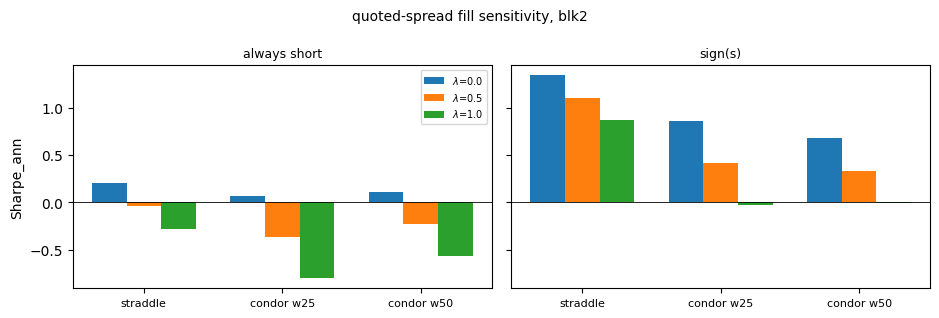

In [15]:
def _tc_leg_ok(bid, ask, sold):
    b = pd.to_numeric(bid, errors="coerce")
    a = pd.to_numeric(ask, errors="coerce")
    base = np.isfinite(b) & np.isfinite(a) & (a >= b) & (b >= 0)
    return base & (b > 0) if sold else base

def _tc_hygiene(df, b, a, label, sold):
    bb, aa = pd.to_numeric(df[b], errors="coerce"), pd.to_numeric(df[a], errors="coerce")
    ok = _tc_leg_ok(bb, aa, sold)
    print(f"hygiene {label:14s} n={len(df)} missing={int((~np.isfinite(bb) | ~np.isfinite(aa)).sum())} "
          f"bid<=0={int((np.isfinite(bb) & (bb <= 0)).sum())} "
          f"bid>ask={int((np.isfinite(bb) & np.isfinite(aa) & (bb > aa)).sum())} "
          f"usable={int(ok.sum())} (strict bid>0: {int(_tc_leg_ok(bb, aa, True).sum())})")
    return ok

px = books["blk2"]
tc_sizes = asl.rule_sizes(px)
TC_RULES = ["always short", "sign(s)"]
TC_LAMS = [0.0, 0.5, 1.0]

ok_c = _tc_hygiene(px, "bid_c", "ask_c", "body call", sold=True)
ok_p = _tc_hygiene(px, "bid_p", "ask_p", "body put", sold=True)
idx_s = common.intersection(px.index[ok_c & ok_p])
print(f"straddle: common={len(common)} scored={len(idx_s)} "
      f"dropped by quote hygiene={len(common) - len(idx_s)}"
      + (" (the lambda=0 rows are the published mid-fill rows)" if len(idx_s) == len(common) else ""))
h_strad = (px["ask_c"] - px["bid_c"]) / 2.0 + (px["ask_p"] - px["bid_p"]) / 2.0
tc_spreads = {
    "body call": float(((px["ask_c"] - px["bid_c"]) / px["mid_c"]).loc[idx_s].median()),
    "body put": float(((px["ask_p"] - px["bid_p"]) / px["mid_p"]).loc[idx_s].median()),
}
rows = {}
for lam in TC_LAMS:
    for rule in TC_RULES:
        q = tc_sizes[rule]
        entry_fill = px["entry"] + np.sign(q) * lam * h_strad
        rp = q * (px["exit"] / entry_fill - 1.0)
        rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx_s], q.loc[idx_s])
tc_tabs = {"straddle": pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]}
print("--- straddle, lambda-fill, blk2 ---")
print(tc_tabs["straddle"].to_string())
tc_tabs["straddle"].to_csv(OUT / "condor_lab_tcost_straddle.csv")

tc_body = atm.reset_index()
tc_close = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
tc_close.index = pd.to_datetime(tc_close.index).tz_localize(None).normalize()
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, tc_body, width=w)
    print(f"width {w}: days with both wings {len(ic)} / body {len(tc_body)}")
    ic = asl.settle_package(ic, tc_close)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].set_index("day")
    joined = ic.join(px[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sz = asl.rule_sizes(joined)
    oks = (_tc_hygiene(joined, "bid_c", "ask_c", f"body C (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_p", "ask_p", f"body P (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_cw", "ask_cw", f"wing C (w{int(w)})", sold=False)
           & _tc_hygiene(joined, "bid_pw", "ask_pw", f"wing P (w{int(w)})", sold=False))
    idx = joined.index[oks].intersection(common)
    print(f"condor w{int(w)}: scored={len(idx)}")
    h_tot = ((joined["ask_c"] - joined["bid_c"]) + (joined["ask_p"] - joined["bid_p"])
             + (joined["ask_cw"] - joined["bid_cw"]) + (joined["ask_pw"] - joined["bid_pw"])) / 2.0
    tc_spreads[f"wing call w{int(w)}"] = float(((joined["ask_cw"] - joined["bid_cw"]) / joined["mid_c_wing"]).loc[idx].median())
    tc_spreads[f"wing put w{int(w)}"] = float(((joined["ask_pw"] - joined["bid_pw"]) / joined["mid_p_wing"]).loc[idx].median())
    base = (joined["exit_ic"] - joined["entry_ic"]) / joined["width"]
    rows = {}
    for lam in TC_LAMS:
        for rule in TC_RULES:
            q = sz[rule]
            rp = q * base - q.abs() * lam * h_tot / joined["width"]
            rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx], q.loc[idx])
    tab = pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]
    print(f"--- iron condor w={int(w)}, defined-risk R, lambda-fill, blk2 ---")
    print(tab.to_string())
    tab.to_csv(OUT / f"condor_lab_tcost_w{int(w)}.csv")
    tc_tabs[f"condor w{int(w)}"] = tab

tc_ero = pd.Series({(inst, rule): tab.loc[("lam=1.0", rule), "Sharpe_ann"] - tab.loc[("lam=0.0", rule), "Sharpe_ann"]
                    for inst, tab in tc_tabs.items() for rule in TC_RULES}).unstack()
print("--- Sharpe erosion: Sharpe(lam=1) - Sharpe(lam=0) ---")
print(tc_ero.to_string())
tc_ero.to_csv(OUT / "condor_lab_tcost_erosion.csv")
tc_sp = pd.Series(tc_spreads, name="median (ask-bid)/mid")
print("--- median relative spread by leg class ---")
print(tc_sp.to_string())
tc_sp.to_csv(OUT / "condor_lab_tcost_spreads.csv")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
xs = np.arange(len(tc_tabs))
for ax, rule in zip(axes, TC_RULES):
    for j, lam in enumerate(TC_LAMS):
        ys = [tc_tabs[k].loc[(f"lam={lam}", rule), "Sharpe_ann"] for k in tc_tabs]
        ax.bar(xs + (j - 1) * 0.25, ys, width=0.25, label=f"$\\lambda$={lam}")
    ax.set_xticks(xs)
    ax.set_xticklabels(list(tc_tabs), fontsize=8)
    ax.set_title(rule, fontsize=9)
    ax.axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
fig.suptitle("quoted-spread fill sensitivity, blk2", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_tcost.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 13. Paired significance on the headline deltas

The `rule_row` $t$'s test each portfolio's mean against zero. The questions
that matter are *differences*: does portfolio $A$ beat portfolio $B$ on the same
days? Let $d_t = R'^{A}_t - R'^{B}_t$ on the common days of the pair.
Two tests, both stated once and applied to every pair:

- **HAC $t$:** $t = \bar d / \widehat{\mathrm{se}}(\bar d)$ with a
  heteroskedasticity- and autocorrelation-consistent standard error
  (Bartlett kernel, truncation lag $L=\lfloor 1.5\,n^{1/3}\rfloor$),
  reported as `HAC_t` with the lag beside it.
- **Circular moving-block bootstrap:** block length
  $b=\lceil n^{1/3}\rceil$, $B=2000$, seed $0$, resampling the pair
  jointly. 95% percentile interval on $\bar d$ and on
  $\Delta\mathrm{Sharpe}_{ann}$ (both portfolios' Sharpes recomputed per
  resample, then differenced), with the basic (reflected) interval
  $[2\hat\theta-\mathrm{hi},\,2\hat\theta-\mathrm{lo}]$ beside it; the
  two agree when the bootstrap distribution is symmetric about the
  estimate. Every pair draws the same block indices
  from the same seed (common random numbers), so the rows' intervals
  are not independent of one another; the same helper serves §15 and
  §16.

Before differencing, each leg is scaled to unit mean gross exposure
(its daily return divided by its mean $|q|$), so `mean_delta_bp` is a
difference per unit of exposure and a smaller portfolio is not read as
a worse one; $\Delta$Sharpe is unaffected by the scaling. The columns
`gross_a` and `gross_b` report the two legs' mean $|q|$.

Pairs: (a) condor $w{=}25$ $\mathrm{sign}(s)$ vs straddle
$\mathrm{sign}(s)$, same blk2 $q_t$ both legs (the published straddle
positions restricted to condor days); (b) spectral PC1 sign vs blk2
$\mathrm{sign}(s)$; (c) EW $\mathrm{sign}(s)$ $q$ vs blk2
$\mathrm{sign}(s)$; (d) blk2 $\mathrm{sign}(s)$ vs always short;
(e) PC1-of-$q$ sign vs blk2 $\mathrm{sign}(s)$; (f) trailing-Sharpe
$\mathrm{sign}(s)$ $q$ vs blk2 $\mathrm{sign}(s)$ — two more ensemble
rows that sit above the benchmark in the tables.

Caveats. In (a) the two returns sit on different denominators
(straddle entry vs condor width), so $\bar d$ is a bookkeeping
comparison of the published portfolio definitions; $\Delta$Sharpe is the
scale-free column. A null here is the expected outcome — nothing in
this lab has beaten the block-diagonal ridge $\mathrm{sign}(s)$
portfolio significantly — these rows say whether the *gaps* in the
ensemble table are distinguishable from noise at all. `mean_delta_bp`
is $\bar d\times 10^4$ per day per unit of exposure; `sig_HAC` is 5%
two-sided. The `verdict_*` columns read the percentile interval in
words: *excludes 0*, *includes 0*, or *knife-edge* when the bound nearer
zero sits within 5% of the interval's width of it — a bare boolean would
overstate such a case either way.

In [16]:
def hac_t(d):
    # HAC t of the mean of a daily series: Bartlett kernel, lag floor(1.5 n^(1/3)), statsmodels
    d = np.asarray(d, float)
    L = int(np.floor(1.5 * len(d) ** (1.0 / 3.0)))
    f = sm.OLS(d, np.ones((len(d), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    return float(f.tvalues[0]), L

def _cmb_idx(n_, B, rng):
    # the library's circular moving-block bootstrap, block length ceil(n^(1/3)); the one helper
    # behind every interval in this notebook (sections 13, 15 and 16) and shared with the deck
    return asl.circular_block_bootstrap_idx(rng, n_, int(np.ceil(n_ ** (1.0 / 3.0))), B)

def _basic(theta, lo, hi):
    # basic (reflected) bootstrap interval from the percentile bounds
    return 2.0 * theta - hi, 2.0 * theta - lo

def _verdict(lo, hi, frac=0.05):
    # 'excludes 0' / 'includes 0'; 'knife-edge' when the bound nearer zero sits within frac of the width of it
    width = hi - lo
    if not width > 0:
        return "degenerate"
    if min(abs(lo), abs(hi)) / width < frac:
        return "knife-edge"
    return "excludes 0" if (lo > 0 or hi < 0) else "includes 0"

def _sharpe(a, axis=None):
    return a.mean(axis=axis) / a.std(axis=axis, ddof=1) * np.sqrt(252.0)

def _unit_gross(rp, q):
    # scale a portfolio's daily return to unit mean gross exposure
    g = float(pd.Series(q).abs().mean()) if q is not None else 1.0
    return (rp / g if g > 0 else rp), g


def pair_row(name, rp, rb, B=2000, qa=None, qb=None):
    rp, ga = _unit_gross(rp, qa)
    rb, gb = _unit_gross(rb, qb)
    a = rp.align(rb, join="inner")
    m = a[0].notna() & a[1].notna()
    x, y = a[0][m].to_numpy(float), a[1][m].to_numpy(float)
    d = x - y
    n_ = len(d)
    t_hac, L = hac_t(d)
    idx = _cmb_idx(n_, B, np.random.default_rng(0))
    dm = d[idx].mean(axis=1)
    lo_m, hi_m = np.percentile(dm, [2.5, 97.5])
    blo_m, bhi_m = _basic(float(d.mean()), lo_m, hi_m)
    ds = _sharpe(x[idx], axis=1) - _sharpe(y[idx], axis=1)
    lo_s, hi_s = np.percentile(ds, [2.5, 97.5])
    dS = float(_sharpe(x) - _sharpe(y))
    blo_s, bhi_s = _basic(dS, lo_s, hi_s)
    return {
        "pair": name, "n": n_, "hac_lag": L,
        "block_len": int(np.ceil(n_ ** (1.0 / 3.0))),
        "gross_a": ga, "gross_b": gb,
        "mean_delta_bp": d.mean() * 1e4, "HAC_t": t_hac,
        "boot_lo_bp": lo_m * 1e4, "boot_hi_bp": hi_m * 1e4,
        "basic_lo_bp": blo_m * 1e4, "basic_hi_bp": bhi_m * 1e4,
        "dSharpe_ann": dS, "dS_lo": lo_s, "dS_hi": hi_s,
        "dS_basic_lo": blo_s, "dS_basic_hi": bhi_s,
        "sig_HAC": abs(t_hac) > 1.96,
        "verdict_mean": _verdict(lo_m, hi_m),
        "verdict_dS": _verdict(lo_s, hi_s),
    }

# condor w=25, credit-vertical wing conventions (asl.pick_wings); blk2 sign(s) positions on both legs
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
ic25 = asl.pick_wings(live, body, width=25.0)
ic25 = asl.settle_package(ic25, close_map)
ic25 = ic25[np.isfinite(ic25["entry_ic"]) & np.isfinite(ic25["exit_ic"]) & (ic25["width"] > 0)].copy()
ic25["R_long_ic"] = (ic25["exit_ic"] - ic25["entry_ic"]) / ic25["width"]
ic25 = ic25.set_index("day")
common_ic = ic25.index.intersection(common).sort_values()
q_blk2 = blk_sizes["sign(s)"]
r_ic_sg = q_blk2.loc[common_ic] * ic25["R_long_ic"].loc[common_ic]
print("condor w25 coverage on common days", len(common_ic), "/", len(common))

_bq = ens_q["blk2 sign(s)"]
sig_tab = pd.DataFrame([
    pair_row("condor25 sign(s) - straddle sign(s) (blk2)", r_ic_sg, ens["blk2 sign(s)"].loc[common_ic],
             qa=q_blk2.loc[common_ic], qb=_bq.loc[common_ic]),
    pair_row("PC1 sign - blk2 sign(s)", ens["spectral PC1 sign"], ens["blk2 sign(s)"],
             qa=ens_q["spectral PC1 sign"], qb=_bq),
    pair_row("EW sign(s) q - blk2 sign(s)", ens["EW sign(s) q"], ens["blk2 sign(s)"],
             qa=ens_q["EW sign(s) q"], qb=_bq),
    pair_row("blk2 sign(s) - always short", ens["blk2 sign(s)"], ens["always short"],
             qa=_bq, qb=ens_q["always short"]),
    pair_row("PC1-of-q sign - blk2 sign(s)", pca_books["PC1-of-q sign"], ens["blk2 sign(s)"],
             qa=pca_q["PC1-of-q sign"], qb=_bq),
    pair_row("trail-Sharpe sign(s) q - blk2 sign(s)", ens["trail-Sharpe sign(s) q"], ens["blk2 sign(s)"],
             qa=ens_q["trail-Sharpe sign(s) q"], qb=_bq),
]).set_index("pair")
print(sig_tab.to_string(float_format=lambda v: f"{v: .3f}"))
sig_tab.to_csv(OUT / "significance_pairs.csv")
print("saved", OUT / "significance_pairs.csv")


condor w25 coverage on common days 866 / 866


                                              n  hac_lag  block_len  gross_a  gross_b  mean_delta_bp  HAC_t  boot_lo_bp  boot_hi_bp  basic_lo_bp  basic_hi_bp  dSharpe_ann  dS_lo  dS_hi  dS_basic_lo  dS_basic_hi  sig_HAC verdict_mean  verdict_dS
pair                                                                                                                                                                                                                                                
condor25 sign(s) - straddle sign(s) (blk2)  866       14         10    1.000    1.000       -819.074 -2.620   -1447.730    -263.335    -1374.812     -190.417       -0.482 -0.963 -0.009       -0.955       -0.001     True   excludes 0  knife-edge
PC1 sign - blk2 sign(s)                     866       14         10    1.000    1.000       -620.582 -1.596   -1307.070     125.772    -1366.936       65.907       -0.878 -1.895  0.188       -1.944        0.139    False   includes 0  includes 0
EW sign(s) q - blk2 

## 14. Why the iron-fly wings do not pay per premium

A defined-risk version of the trade, parked in the main notebook and explored here, wraps it in an iron fly — a wing bought
on each side of the body whenever the portfolio sells, which turns the
short straddle into two credit spreads — and keeps it as a venue
constraint, the defined-risk structure a retail margin account
requires on cash-settled SPX or XSP, not as an improvement. Per dollar
of body premium the wings do not help: the $\mathrm{sign}(s)$
portfolio loses Sharpe (1.16 with wings 25 points out and 1.28 at 50 points,
against 1.34 without wings on the same days), the always-short control
loses what little edge it had, and compounded wealth suffers in
proportion. The only frame in which the wings look free is index
points per package, and even there the sign runs the other way: over
the whole sample the wings returned about 0.007 points a day *more*
than they cost, with a paired $t$-statistic of essentially zero.
(`drag_both` is wing premium paid minus wing settlement received, so
its negative mean is a small net gain, not a cost.) This section asks why, so
that the construction can be revisited with the right question rather
than dropped.

The portfolio is rebuilt here exactly as the parked deck section built it. The
body is the 15:30 nearest-out-of-the-money package; the wings are the
nearest live 15:30 midpoint quotes at least $w$ points further out of
the money; the package is settled in cash at the official close; the
net credit is body premium minus wing premium, and days with a
non-positive credit are dropped with a printed count; the seller's
worst case is the larger actual wing gap minus the credit. Returns are
per dollar of body premium throughout, on the same days and with the
same denominator for the hedged and the plain portfolio, so every
comparison is like against like. The cell first reproduces the parked section's
headline at 25 points and stops if it cannot.

Four questions follow.

1. *Where does the wing cost come from?* For each year, the premium
   paid for the wings on an average day against what they pay back at
   settlement, and how much of the payback arrives on the few days the
   settlement lands beyond a wing. The accounting is repeated with the
   body sold at the bid and the wings bought at the ask, because deep
   out-of-the-money wings are quoted with very wide spreads relative to
   their price.
2. *Does one wing do the work?* The crash tail of an index is
   asymmetric, so the put wing alone and the call wing alone are scored
   against both wings and none.
3. *Is there a width at which the hedged portfolio wins?* The width ladder
   of §8 — fixed gaps of 10 to 100 points, including the 20- and
   30-point wings the parked section reported, and gaps scaled to the package price —
   scored per premium on the $\mathrm{sign}(s)$ composite,
   with the share of selling days on which the settlement reaches a
   wing.
4. *When do the wings pay?* The distribution of how far the settlement
   travels from the body strike, in units of the wing gap, and the
   per-year Sharpe ratios of the hedged and plain portfolios, to see whether
   the wings earn their keep only in the crash year.

**What the exploration shows.** The wings do not pay per dollar of
premium in any configuration tried, and the tables say why. The cost
is not the midpoint premium: at midpoint quotes the wings roughly pay
for themselves over the whole sample. It is concentration. Essentially
all of the payback arrived in 2020 — at 25 points, 249 of the 398
points ever returned beyond a wing, and a net gain of 152 points that
year against a net cost in every year since — so the "free insurance"
is one crash year's payouts spread over four years of premium, and its
worst weeks sit inside the first 63 sessions that the deck's other
slides exclude as their estimation window. On the days that
matter for the $\mathrm{sign}(s)$ portfolio the settlement rarely travels far: on
selling days the median settlement sits a sixth of the way from the
body strike to a 25-point wing, and reaches the wing on 4.6% of them
(1.3% at 50 points). The expensive wing is the put wing: alone it
costs almost as much Sharpe as both wings, while the call wing is
nearly free. Neither, though, shortens the $\mathrm{sign}(s)$
portfolio's worst day. That day's settlement runs *up*, so the put wing
only adds its premium to the loss and makes the worst day worse at
every width. Only at $w=20$ does anything shorten it — the call wing
alone ($-4.66$) and the pair ($-4.68$) — and at every wider gap both
are worse than the plain $-5.42$. The put wing does cap the always-short control's
worst day — that control is short on the crash day, when the put wing
pays — which is where the reading that the put wing is the protective
one comes from; for the traded rule it does not hold. The
`worst_hedged` and `worst_plain` columns of the one-sided table print
both, at every width. No width on the ladder beats the plain portfolio
— the best is 50 points, 0.06 of Sharpe behind with a paired $t$ of
$-1.8$ — and the gap is negative for all eight forecasts. At the 20-
and 30-point wings the parked section reported, the $\mathrm{sign}(s)$ portfolio gives up 0.22 and
0.13 of Sharpe (paired $t$ of $-2.4$ and $-1.8$) and the settlement
reaches a wing on 8.1% and 2.7% of selling days. Paying the quoted
spread makes it worse: with the wings bought at the ask, which is
quoted at 1.2 to 2 times their midpoint, they cost 0.09 points a
day and the $\mathrm{sign}(s)$ portfolio gives up 0.3 of Sharpe at 25 points
against the plain portfolio filled the same way.

**What the construction still owes**, as questions rather than claims.
Would wings placed by delta, or by the forecast itself — wider when
the forecast is calm, tighter when it is not — change the ratio of
cost to coverage, given that the cap is reached on about one selling
day in twenty? Would hedging conditionally, only on days some measure
flags elevated risk, buy the protection where it is cheap relative to
the payoff? (§15 tries the lagged signal's rank as that measure and
finds it points at the wrong tail.) And is the crash-year payoff a property of the instrument or
of one event?

gate: wings-minus-none accounting identity, max residual 0.00e+00 points
gate: plain leg vs the deck's sign(s) portfolio, max |difference| 1.95e-07 (quote rounding)
gate: w=25 scored days 866 of 866 common days (0 dropped by the credit>0 filter)
gate: the plain leg reproduces the deck's rule table sign(s) Sharpe to 1.07e-08
gate: w=25 sign(s) per premium, hedged Sharpe 1.1586 against plain 1.3383; wing drag all days -0.0070 pts/day (positive = the wings cost money)
gate passed
=== (a) wing premium paid vs wing settlement received, index points per package ===
                                 days  wing_premium_paid  wing_settlement_received  net_cost  days_beyond_wing  pts_returned_on_those_days
w  frame                   year                                                                                                           
25 all days (always short) all    866              0.669                     0.676    -0.007                35                     397.975
                 

w=50: wing cost at mid -0.028 pts/day (HAC t -0.29); wings at the ask +0.044 pts/day (HAC t +0.53); median wing ask/mid 2.00
                  days  Sharpe_always_short  Sharpe_sign_s  worst_sign_s
w  fill                                                                 
20 mid, plain      866                0.204          1.338        -5.422
   mid, wings      866               -0.203          1.115        -4.676
   spread, plain   866               -0.262          0.870        -5.451
   spread, wings   866               -0.960          0.503        -4.718
25 mid, plain      866                0.204          1.338        -5.422
   mid, wings      866               -0.109          1.159        -5.437
   spread, plain   866               -0.262          0.870        -5.451
   spread, wings   866               -0.813          0.572        -5.479
30 mid, plain      866                0.204          1.338        -5.422
   mid, wings      866               -0.045          1.210        -5.437

                       Sharpe_hedged  Sharpe_plain  HAC_t_diff  worst_hedged  wing_cost_pts_per_sell_day  pct_sell_days_beyond_wing
w  wings rule                                                                                                                      
20 none  always short          0.204         0.204         NaN       -10.316                       0.000                      0.000
         sign(s)               1.338         1.338         NaN        -5.422                       0.000                      0.000
   put   always short         -0.120         0.204      -2.747        -6.852                       0.135                      3.464
         sign(s)               1.139         1.338      -2.790        -5.444                       0.082                      4.038
   call  always short          0.140         0.204      -0.585       -10.324                      -0.099                      3.233
         sign(s)               1.315         1.338      -0.653        -4.655

                             n  med_gap  Sharpe_hedged  Sharpe_plain  dSharpe  HAC_t_diff  worst_hedged  worst_plain  wing_cost_pts_per_sell_day  pct_sell_days_beyond_wing
width    rule                                                                                                                                                              
w10      always short  866.000   10.000         -0.403         0.204   -0.607      -1.708        -5.656      -10.316                       0.070                     22.286
         sign(s)       866.000   10.000          0.979         1.338   -0.359      -2.459        -3.881       -5.422                       0.062                     24.231
w20      always short  866.000   20.000         -0.203         0.204   -0.407      -2.320        -6.869      -10.316                       0.035                      6.697
         sign(s)       866.000   20.000          1.115         1.338   -0.223      -2.394        -4.676       -5.422                      -0

                                                   Sharpe_hedged  Sharpe_plain  dSharpe  HAC_t_diff  worst_hedged  worst_plain
model                                          w                                                                              
baseline (HAR + calendar OLS)                  25          0.725         0.967   -0.242      -2.975        -5.437       -5.422
                                               50          0.883         0.967   -0.085      -2.507        -5.437       -5.422
block-diagonal ridge                           25          1.159         1.338   -0.180      -2.193        -5.437       -5.422
                                               50          1.280         1.338   -0.058      -1.766        -5.437       -5.422
block-diagonal ridge, without the FOMC columns 25          1.117         1.271   -0.154      -1.925        -5.437       -5.422
                                               50          1.215         1.271   -0.056      -1.702        -5.4

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\vert_lab_width_ladder.png


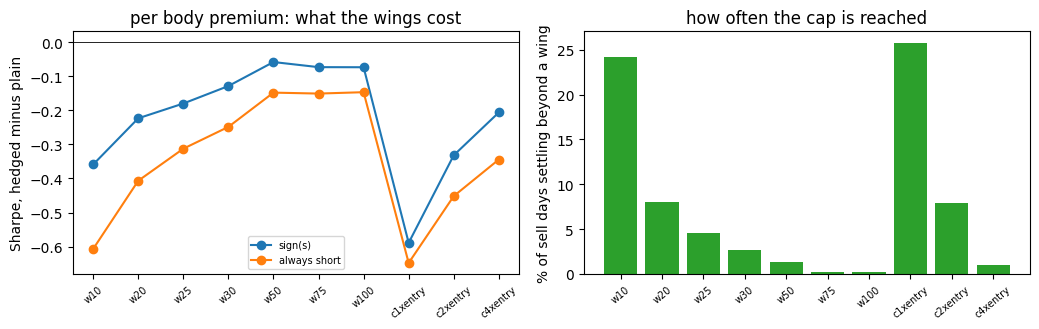

In [17]:
# --- the iron-fly portfolio, rebuilt exactly as the parked RV-IV deck section built it ---
vl_body = atm.reset_index()
vl_close = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
vl_close.index = pd.to_datetime(vl_close.index).tz_localize(None).normalize()

def vl_settle(raw):
    vs = asl.settle_package(raw, vl_close)
    vs = vs[np.isfinite(vs["entry_ic"]) & np.isfinite(vs["exit_ic"]) & (vs["width"] > 0)].copy()
    vs["credit"] = vs["entry_ic"]
    vs["gap_c"] = vs["K_c_wing"] - vs["K_c"]
    vs["gap_p"] = vs["K_p"] - vs["K_p_wing"]
    vs["gap_max"] = np.maximum(vs["gap_c"], vs["gap_p"])
    vs = vs[(vs["credit"] > 0) & (vs["credit"] < vs["gap_max"])].copy()
    # package P&L in index points for a seller, four wing configurations
    vs["pnl_none"] = vs["entry_body"] - vs["exit"]
    vs["pnl_both"] = vs["credit"] - vs["exit_ic"]
    vs["pnl_put"] = (vs["entry_body"] - vs["mid_p_wing"]) - (vs["exit"] - vs["pay_p_wing"])
    vs["pnl_call"] = (vs["entry_body"] - vs["mid_c_wing"]) - (vs["exit"] - vs["pay_c_wing"])
    # what each wing costs net of what it pays back (positive = the wing cost money that day)
    vs["drag_both"] = vs["entry_wings"] - vs["exit_wings"]
    vs["drag_put"] = vs["mid_p_wing"] - vs["pay_p_wing"]
    vs["drag_call"] = vs["mid_c_wing"] - vs["pay_c_wing"]
    vs["drag_none"] = 0.0
    vs["beyond_call"] = vs["S_close"] >= vs["K_c_wing"]
    vs["beyond_put"] = vs["S_close"] <= vs["K_p_wing"]
    vs["beyond_both"] = vs["beyond_call"] | vs["beyond_put"]
    vs["beyond_none"] = False
    # settlement distance from the body strike, in units of the wing gap on that side (0 inside the body)
    up = (vs["S_close"] - vs["K_c"]) / vs["gap_c"]
    dn = (vs["K_p"] - vs["S_close"]) / vs["gap_p"]
    vs["dist_gap"] = np.maximum(np.maximum(up, dn), 0.0)
    return vs.set_index("day").sort_index()

def vl_book(width=None, w_row=None):
    raw = asl.pick_wings(live, vl_body, width=width) if w_row is None else pick_wings_perday(live, vl_body, w_row)
    return vl_settle(raw)

def vl_rows(vs, px, cfg="both"):
    # per-premium rows for the two rules; the hedged portfolio against the plain portfolio on the same days
    j = vs.join(px[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    hedged = j[f"pnl_{cfg}"] / j["entry_body"]
    out = {}
    for name, h, plain, sell in (
        ("always short", hedged, -j["R"], pd.Series(True, index=j.index)),
        ("sign(s)", hedged.where(j["pos"] < 0, j["R"]), j["pos"] * j["R"], j["pos"] < 0),
    ):
        _d = (h - plain).to_numpy(float)
        # cfg="none" is the plain portfolio: there is no difference to test, and a HAC t on a
        # series of float noise around zero is not a number worth printing
        t_hac = float("nan") if np.abs(_d).max() < 1e-12 else hac_t(_d)[0]
        out[name] = pd.Series({
            "n": len(j),
            "Sharpe_hedged": _sharpe(h), "Sharpe_plain": _sharpe(plain), "dSharpe": _sharpe(h) - _sharpe(plain),
            "HAC_t_diff": t_hac,
            "worst_hedged": float(h.min()), "worst_plain": float(plain.min()),
            "wing_cost_pts_per_sell_day": float(j.loc[sell, f"drag_{cfg}"].mean()),
            "pct_sell_days_beyond_wing": 100.0 * float(j.loc[sell, f"beyond_{cfg}"].mean()),
        })
    return pd.DataFrame(out).T, j

px_b = books["blk2"]
vl = {w: vl_book(width=w) for w in (25.0, 50.0)}
# the wing widths the parked iron-fly section of the main notebook reports, for the fills and one-sided tables
vl_wide = {w: (vl[w] if w in vl else vl_book(width=w)) for w in (20.0, 25.0, 30.0, 50.0)}

# --- gate: the rebuilt portfolio must satisfy its own accounting identity and its plain leg must
#     be the deck's sign(s) portfolio on the same days. Both sides are recomputed on the current
#     frame; no headline number from an earlier frame is asserted. ---
rows25, j25 = vl_rows(vl[25.0], px_b)
_resid = float((j25["pnl_both"] - (j25["pnl_none"] - j25["drag_both"])).abs().max())
print(f"gate: wings-minus-none accounting identity, max residual {_resid:.2e} points")
assert _resid < 1e-9
_plain25 = j25["pos"] * j25["R"]
_dev25 = float((_plain25 - deck_ref.loc[j25.index]).abs().max())
print(f"gate: plain leg vs the deck's sign(s) portfolio, max |difference| {_dev25:.2e} (quote rounding)")
assert _dev25 < 1e-5
_rt25 = pd.read_csv(OUT / "rule_table_blk2.csv", index_col=0)
print(f"gate: w=25 scored days {len(j25)} of {len(common)} common days "
      f"({len(common) - len(j25)} dropped by the credit>0 filter)")
if len(j25) == len(common):
    _dsh25 = abs(_sharpe(_plain25) - float(_rt25.loc["sign(s)", "Sharpe_ann"]))
    print(f"gate: the plain leg reproduces the deck's rule table sign(s) Sharpe to {_dsh25:.2e}")
    assert _dsh25 < 1e-6
print(f"gate: w=25 sign(s) per premium, hedged Sharpe {rows25.loc['sign(s)', 'Sharpe_hedged']:.4f} "
      f"against plain {rows25.loc['sign(s)', 'Sharpe_plain']:.4f}; "
      f"wing drag all days {float(j25['drag_both'].mean()):+.4f} pts/day "
      "(positive = the wings cost money)")
# kept for the cross-gate check in section 15 (j25 is rebuilt later in this cell)
gate14_days = j25.index.copy()
gate14_plain_sharpe = float(rows25.loc["sign(s)", "Sharpe_plain"])
print("gate passed")

# (a) where the wing cost comes from: premium paid vs settlement received, by year
print("=== (a) wing premium paid vs wing settlement received, index points per package ===")
dec_rows = []
for w, vs in vl.items():
    j = vs.join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    for frame, mask in (("all days (always short)", pd.Series(True, index=j.index)), ("sell days (sign(s))", j["pos"] < 0)):
        g = j.loc[mask]
        for yr, gy in [("all", g)] + list(g.groupby(g.index.year)):
            dec_rows.append({
                "w": int(w), "frame": frame, "year": yr, "days": len(gy),
                "wing_premium_paid": float(gy["entry_wings"].mean()),
                "wing_settlement_received": float(gy["exit_wings"].mean()),
                "net_cost": float(gy["drag_both"].mean()),
                "days_beyond_wing": int(gy["beyond_both"].sum()),
                "pts_returned_on_those_days": float((gy["exit_wings"] - gy["entry_wings"])[gy["beyond_both"]].sum()),
            })
vl_dec = pd.DataFrame(dec_rows).set_index(["w", "frame", "year"])
print(vl_dec.to_string(float_format=lambda v: f"{v: .3f}"))
vl_dec.to_csv(OUT / "vert_lab_wing_cost_by_year_blk2.csv")

# (a2) realistic fills: body sold at the bid, wings bought at the ask; buy days pay the ask on the body
print("=== (a2) paying the quoted spread: body at the bid, wings at the ask ===")
fill_rows = []
for w, vs in vl_wide.items():
    j = vs.join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    ok = (_tc_leg_ok(j["bid_c"], j["ask_c"], True) & _tc_leg_ok(j["bid_p"], j["ask_p"], True)
          & _tc_leg_ok(j["bid_cw"], j["ask_cw"], False) & _tc_leg_ok(j["bid_pw"], j["ask_pw"], False))
    j = j.loc[ok]
    body_bid = j["bid_c"].astype(float) + j["bid_p"].astype(float)
    body_ask = j["ask_c"].astype(float) + j["ask_p"].astype(float)
    wings_ask = j["ask_cw"].astype(float) + j["ask_pw"].astype(float)
    denom = j["entry_body"]  # the mid premium stays the unit; only the fills move
    sell = j["pos"] < 0
    books_x = {
        "mid, plain": (j["pnl_none"] / denom, (j["exit"] - j["entry_body"]) / denom),
        "mid, wings": (j["pnl_both"] / denom, (j["exit"] - j["entry_body"]) / denom),
        "spread, plain": ((body_bid - j["exit"]) / denom, (j["exit"] - body_ask) / denom),
        "spread, wings": ((body_bid - wings_ask - j["exit_ic"]) / denom, (j["exit"] - body_ask) / denom),
    }
    drag_x = wings_ask - j["exit_wings"]
    for label, (short_leg, long_leg) in books_x.items():
        as_ = short_leg
        ls = short_leg.where(sell, long_leg)
        fill_rows.append({"w": int(w), "fill": label, "days": len(j),
                          "Sharpe_always_short": _sharpe(as_), "Sharpe_sign_s": _sharpe(ls),
                          "worst_sign_s": float(ls.min())})
    t_mid, _ = hac_t(j["drag_both"].to_numpy(float))
    t_x, _ = hac_t(drag_x.to_numpy(float))
    print(f"w={int(w)}: wing cost at mid {float(j['drag_both'].mean()):+.3f} pts/day (HAC t {t_mid:+.2f}); "
          f"wings at the ask {float(drag_x.mean()):+.3f} pts/day (HAC t {t_x:+.2f}); "
          f"median wing ask/mid {float((wings_ask / j['entry_wings']).median()):.2f}")
vl_fill = pd.DataFrame(fill_rows).set_index(["w", "fill"])
print(vl_fill.to_string(float_format=lambda v: f"{v: .3f}"))
vl_fill.to_csv(OUT / "vert_lab_fills_blk2.csv")

# (b) one wing at a time
print("=== (b) one-sided wings on sell days, per body premium, blk2 ===")
side_rows = []
for w, vs in vl_wide.items():
    for cfg in ("none", "put", "call", "both"):
        r, _ = vl_rows(vs, px_b, cfg=cfg)
        for name, row in r.iterrows():
            side_rows.append({"w": int(w), "wings": cfg, "rule": name, **row.to_dict()})
vl_side = pd.DataFrame(side_rows).set_index(["w", "wings", "rule"])
print(vl_side[["Sharpe_hedged", "Sharpe_plain", "HAC_t_diff", "worst_hedged", "wing_cost_pts_per_sell_day",
               "pct_sell_days_beyond_wing"]].to_string(float_format=lambda v: f"{v: .3f}"))
vl_side.to_csv(OUT / "vert_lab_one_sided_blk2.csv")

# (c) the width ladder, per body premium
print("=== (c) width ladder, wings on sell days, per body premium, blk2 ===")
lad_books = {f"w{int(w)}": (vl_wide[w] if w in vl_wide else vl_book(width=w))
             for w in (10.0, 20.0, 25.0, 30.0, 50.0, 75.0, 100.0)}
for cmult in (1.0, 2.0, 4.0):
    lad_books[f"c{int(cmult)}xentry"] = vl_book(w_row=cmult * vl_body["entry"].to_numpy(float))
lad_rows = []
for label, vs in lad_books.items():
    r, j = vl_rows(vs, px_b)
    for name, row in r.iterrows():
        lad_rows.append({"width": label, "rule": name, "med_gap": float(j["gap_max"].median()), **row.to_dict()})
vl_lad = pd.DataFrame(lad_rows).set_index(["width", "rule"])
print(vl_lad[["n", "med_gap", "Sharpe_hedged", "Sharpe_plain", "dSharpe", "HAC_t_diff", "worst_hedged", "worst_plain",
              "wing_cost_pts_per_sell_day", "pct_sell_days_beyond_wing"]].to_string(float_format=lambda v: f"{v: .3f}"))
vl_lad.to_csv(OUT / "vert_lab_width_ladder_blk2.csv")
best = vl_lad.xs("sign(s)", level="rule")["dSharpe"]
print("sign(s): any width where the hedged portfolio beats the plain portfolio per premium?",
      ("yes: " + ", ".join(best[best > 0].index)) if (best > 0).any() else "no")

# (d) when the wings pay: how far the settlement travels, and per-year portfolios
print("=== (d) settlement distance from the body strike in wing-gap units, sell days ===")
dist_rows = {}
for w, vs in vl.items():
    j = vs.join(px_b[["pos"]], how="inner")
    d = j.loc[(j.index.isin(common)) & (j["pos"] < 0), "dist_gap"]
    dist_rows[f"w{int(w)}"] = pd.Series({
        "sell days": len(d), "share inside body": float((d == 0).mean()),
        "q50": float(d.quantile(0.5)), "q75": float(d.quantile(0.75)), "q90": float(d.quantile(0.9)),
        "q95": float(d.quantile(0.95)), "q99": float(d.quantile(0.99)),
        "share between half-gap and wing": float(((d >= 0.5) & (d < 1)).mean()),
        "share beyond wing": float((d >= 1).mean()),
    })
vl_dist = pd.DataFrame(dist_rows)
print(vl_dist.to_string(float_format=lambda v: f"{v: .3f}"))
vl_dist.to_csv(OUT / "vert_lab_settle_distance_blk2.csv")

print("=== (d2) per-year Sharpe, plain vs hedged, and the points the wings hand back, blk2 ===")
yr_rows = []
j25 = vl[25.0].join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
j25 = j25.loc[j25.index.intersection(common)]
j50 = vl[50.0].join(px_b[["pos", "R"]], how="inner", rsuffix="_strad").loc[j25.index]
for yr, g in j25.groupby(j25.index.year):
    g50 = j50.loc[g.index]
    ls_plain = g["pos"] * g["R"]
    row = {"year": yr, "days": len(g),
           "LS plain": _sharpe(ls_plain),
           "LS w25": _sharpe((g["pnl_both"] / g["entry_body"]).where(g["pos"] < 0, g["R"])),
           "LS w50": _sharpe((g50["pnl_both"] / g50["entry_body"]).where(g50["pos"] < 0, g50["R"])),
           "AS plain": _sharpe(-g["R"]),
           "AS w25": _sharpe(g["pnl_both"] / g["entry_body"]),
           "AS w50": _sharpe(g50["pnl_both"] / g50["entry_body"]),
           "w25 pts returned beyond wing": float((g["exit_wings"] - g["entry_wings"])[g["beyond_both"]].sum()),
           "w25 wing cost, all days": float(g["drag_both"].sum()),
           "w50 pts returned beyond wing": float((g50["exit_wings"] - g50["entry_wings"])[g50["beyond_both"]].sum()),
           "w50 wing cost, all days": float(g50["drag_both"].sum())}
    yr_rows.append(row)
vl_year = pd.DataFrame(yr_rows).set_index("year")
print(vl_year.to_string(float_format=lambda v: f"{v: .3f}"))
vl_year.to_csv(OUT / "vert_lab_per_year_blk2.csv")

# every forecast, sign(s) per premium, hedged vs plain
print(f"=== all {len(MODEL_ORDER)} forecasts: sign(s) per premium, wings on sell days vs none ===")
mod_rows = []
for tag in MODEL_ORDER:
    for w, vs in vl.items():
        r, _ = vl_rows(vs, books[tag])
        row = r.loc["sign(s)"]
        mod_rows.append({"model": LABEL[tag], "w": int(w), "Sharpe_hedged": row["Sharpe_hedged"],
                         "Sharpe_plain": row["Sharpe_plain"], "dSharpe": row["dSharpe"], "HAC_t_diff": row["HAC_t_diff"],
                         "worst_hedged": row["worst_hedged"], "worst_plain": row["worst_plain"]})
vl_mod = pd.DataFrame(mod_rows).set_index(["model", "w"])
print(vl_mod.to_string(float_format=lambda v: f"{v: .3f}"))
vl_mod.to_csv(OUT / "vert_lab_models.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
order = ["w10", "w20", "w25", "w30", "w50", "w75", "w100", "c1xentry", "c2xentry", "c4xentry"]
xs = np.arange(len(order))
for name, c in (("sign(s)", "C0"), ("always short", "C1")):
    sub = vl_lad.xs(name, level="rule").loc[order]
    axes[0].plot(xs, sub["dSharpe"], marker="o", color=c, label=name)
axes[0].axhline(0.0, color="k", lw=0.6)
axes[0].set_xticks(xs, order, rotation=40, fontsize=7)
axes[0].set_ylabel("Sharpe, hedged minus plain")
axes[0].set_title("per body premium: what the wings cost")
axes[0].legend(fontsize=7)
sub = vl_lad.xs("sign(s)", level="rule").loc[order]
axes[1].bar(xs, sub["pct_sell_days_beyond_wing"], color="C2")
axes[1].set_xticks(xs, order, rotation=40, fontsize=7)
axes[1].set_ylabel("% of sell days settling beyond a wing")
axes[1].set_title("how often the cap is reached")
fig.tight_layout()
fig.savefig(OUT / "vert_lab_width_ladder.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "vert_lab_width_ladder.png")
display(fig)
plt.close(fig)


## 15. Cutting exposure on days the lagged signal flags risk

Yesterday's signal does not predict today's return, but days on which
its percentile rank was high do show larger settlement moves on
average — the flagged-against-unflagged comparison printed below.
Taken at face value that reads like a day-ahead risk flag, and wings
have already failed to manage the sell-side tail (§14). This section asks the natural
follow-up: does stepping aside on the days the lagged signal flags as
risky improve the tail of the $\mathrm{sign}(s)$ portfolio?

**Construction.** The flag is the percentile rank of $s_{t-1}$ among all days up to $t-1$, computed from
past data only once at least 63 days of history exist. Three flags are
declared here, before any result is read, and none is chosen after the
fact:

- **primary** — the top tercile of the rank of $s_{t-1}$, the
  regressor of the lagged-magnitude reading (parked in the main
  notebook; the deck shows the plain regression);
- alternate — the bottom tercile of the same rank (yesterday's implied
  variance far above the forecast), in case the sell-side tail lives at
  that end;
- alternate — the top tercile of the rank of $|s_{t-1}|$, the unsigned
  version.

Two rules are scored on the $\mathrm{sign}(s)$ portfolio, which sells the package
when the same-day signal is negative and buys it otherwise: rule A is
flat on every flagged day; rule B is flat on a flagged day only when
the same-day rule would sell, since a bought package already risks no
more than its premium. Rule A is also applied to the always-short
control. Days before the rank exists are traded as usual in both the
flagged and the reference portfolio, so every comparison is on the same
common days; the count is printed by the cell. The criterion is the
tail — worst day, maximum drawdown, annual volatility, excess kurtosis,
and the worst day of each calendar year — with mean and Sharpe reported
beside it. Each rule is tested against the reference with a
heteroskedasticity- and autocorrelation-consistent $t$ on the daily
difference (Bartlett kernel, lag $\lfloor 1.5\,n^{1/3}\rfloor$) and a
circular block bootstrap on the Sharpe change (the §13 helper,
percentile and basic intervals), and against a placebo: every circular
shift of the real flag *within the days on which the flag can be
evaluated*, which keeps the number of flagged days, their run lengths
and the warm-up gap exactly, so that a flag which helps only by trading
fewer days sits at the placebo median. Restricting the shift matters:
the rank needs 63 days of history plus a one-day lag, so the flag is
structurally false over the opening stretch, and an unrestricted
placebo would put flagged days where the real flag could never be.
Percentiles are mid-ranks (a tie counts half), and the share of shifts
that leave a statistic exactly unchanged is printed beside them — a
worst day that no placebo touches is a tie, not a win. A count-matched
random draw from the same eligible days is kept as a second line. The
maximum drawdown percentile is reported with its tie share and has to
be read that way: the reference drawdown opens before the flag's first
eligible day, so a placebo that puts no flagged day inside the drawdown
window leaves the drawdown exactly unchanged, and those ties carry most
of the distribution. The cell prints the peak and trough dates, where
they sit relative to the warm-up, and the tie share beside the
percentile. The
cell first checks that the flag reads nothing after $t-1$ and that the
reference row reproduces the deck's regenerated `daily_blk2.parquet`
and `rule_table_blk2.csv` day for day, and that the three places this
notebook scores the plain $\mathrm{sign}(s)$ portfolio (§12 at
$\lambda=0$, §14's plain leg, §15's reference) are the same portfolio on
the same days. It then shows where the sell-side
losses actually sit — selling days split by tercile of the lagged rank
— and what the flag sacrifices against what it protects: the share of
the reference return earned on flagged days against the share of the
ten worst days' losses that fell on them, with a placebo percentile for
the latter.

**What it shows: a negative result.** The flag does not reach the
tail. Under every flag and both rules, for all eight forecast tables, the
worst day is unchanged — 48 of 48 table-flag-rule cells, the ridge's at
$-5.42$ — and neither portfolio's worst day is flagged. The maximum
drawdown is unchanged for the ridge under the primary flag, but across
the eight tables it moves in 30 of those 48 cells and in both
directions ($-7.8$ to $+4.2$ points), so the flag does not shorten the
drawdown either. The primary rule cuts the Sharpe ratio
from 1.34 to 1.14 and roughly doubles the excess kurtosis, because it
inserts zeros on ordinary days and leaves the extremes in place. The
reason is that the flag points at the wrong tail. Yesterday's forecast
sitting far above implied variance persists into today's sign, so the
top tercile of the lagged rank is only about 45 percent selling days
(the bottom tercile is about 80 percent): the flag mostly removes
*buying* days, whose large settlement moves are the portfolio's profit, not
its loss — a bought package cannot lose more than its premium. The
selling days that hurt sit in the *middle* tercile (187 selling days,
worst $-5.42$, ten days below $-2$), against five such days in the
top tercile and three in the bottom. Flagged days carry about 29
percent of the reference return but only about 21 percent of the ten
worst days' losses, and shifted flags cover more of the worst days'
losses than this one on about 79 percent of shifts. A
no-forecast comparator — the top tercile of yesterday's realized
$|R|$ — separates large from small moves better than the lagged signal
does.

This reinterprets the lagged-magnitude reading (parked in the main
notebook). The lagged rank
predicts the *size* of the settlement move, and on buying days that
size is the payoff; it is not a warning about the short side. Any
control of the sell-side tail would have to condition on selling days
and on a quantity that separates the middle-tercile losses from the
rest — which this one does not — and whether such a quantity exists in
the 15:30 information set is the open question.

causality: flags for days <= t unchanged by perturbing R or s on days >= t (10 draws)
reference sign(s), block-diagonal ridge: n 866 mean 0.0947 Sharpe 1.338
gate: against the deck's regenerated outputs, max |daily difference| 1.95e-07, |mean difference| 6.41e-10, |Sharpe difference| 1.07e-08 (quote rounding)
plain sign(s), the three gates in this notebook:
  S12 lambda=0, quoted subset        n= 866  Sharpe 1.3383
  S14 plain leg, credit>0 days       n= 866  Sharpe 1.3383
  S15 reference, all common days     n= 866  Sharpe 1.3383
  the three gates score the same days and agree to 1e-8
reference maximum drawdown -17.702 points, peak 2020-01-08 trough 2020-05-04; the flag is undefined on the first 63 sessions (the rank needs 63 days of history plus the one-day lag), so every placebo below is drawn from the 803 eligible days only.
  the drawdown opens on day 3 of 866 and closes on day 55, so it overlaps that ineligible span: read placebo_pct_maxDD_pts beside tie_pct_maxDD_pts, because a 

saved riskflag_summary_<model>.csv in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530
across 8 forecasts x 3 flags x 2 rules = 48 cells: worst day unchanged in 48, maximum drawdown unchanged in 18; drawdown changes span -7.83 to +4.24 points

=== flag: top tercile of rank(s_{t-1}) [primary] --- block-diagonal ridge, 866 days, 803 eligible ===
                                                  n    mean  Sharpe_ann  vol_ann  worst_day  maxDD_pts  ex_kurt  flagged_days  flagged_sell_days
rule                                                                                                                                            
reference sign(s)                         +866.0000 +0.0947     +1.3383 +17.8384    -5.4225   -17.7022 +10.6122     +263.0000          +117.0000
A: flat on flagged days                   +866.0000 +0.0675     +1.1387 +14.9432    -5.4225   -17.7022 +21.8734     +263.0000          +117.0000
B: flat on flagged days only when selling +

paired against the reference (HAC t on the daily difference, Bartlett kernel; circular block-bootstrap 95% percentile and basic intervals on the Sharpe change)
placebo percentiles (mid-rank, ties count half): where the realized change sits among all 802 circular shifts of the real flag within the eligible days;
tie_pct_* is the share of shifts that leave the statistic exactly unchanged; subset_pct_* repeats the read against 2000 count-matched random draws from the eligible days:
                                           mean_delta  HAC_t  hac_lag  dSharpe  boot_lo  boot_hi  boot_basic_lo  boot_basic_hi verdict_dSharpe  worst_day_change  maxDD_pts_change  placebo_pct_worst  placebo_pct_maxDD_pts  placebo_pct_dSharpe  tie_pct_worst  tie_pct_maxDD_pts  tie_pct_dSharpe  subset_pct_worst  subset_pct_maxDD_pts  subset_pct_dSharpe
rule                                                                                                                                                               

paired against the reference (HAC t on the daily difference, Bartlett kernel; circular block-bootstrap 95% percentile and basic intervals on the Sharpe change)
placebo percentiles (mid-rank, ties count half): where the realized change sits among all 802 circular shifts of the real flag within the eligible days;
tie_pct_* is the share of shifts that leave the statistic exactly unchanged; subset_pct_* repeats the read against 2000 count-matched random draws from the eligible days:
                                           mean_delta  HAC_t  hac_lag  dSharpe  boot_lo  boot_hi  boot_basic_lo  boot_basic_hi verdict_dSharpe  worst_day_change  maxDD_pts_change  placebo_pct_worst  placebo_pct_maxDD_pts  placebo_pct_dSharpe  tie_pct_worst  tie_pct_maxDD_pts  tie_pct_dSharpe  subset_pct_worst  subset_pct_maxDD_pts  subset_pct_dSharpe
rule                                                                                                                                                               

paired against the reference (HAC t on the daily difference, Bartlett kernel; circular block-bootstrap 95% percentile and basic intervals on the Sharpe change)
placebo percentiles (mid-rank, ties count half): where the realized change sits among all 802 circular shifts of the real flag within the eligible days;
tie_pct_* is the share of shifts that leave the statistic exactly unchanged; subset_pct_* repeats the read against 2000 count-matched random draws from the eligible days:
                                           mean_delta  HAC_t  hac_lag  dSharpe  boot_lo  boot_hi  boot_basic_lo  boot_basic_hi verdict_dSharpe  worst_day_change  maxDD_pts_change  placebo_pct_worst  placebo_pct_maxDD_pts  placebo_pct_dSharpe  tie_pct_worst  tie_pct_maxDD_pts  tie_pct_dSharpe  subset_pct_worst  subset_pct_maxDD_pts  subset_pct_dSharpe
rule                                                                                                                                                               

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\riskflag_cum_blk2.png


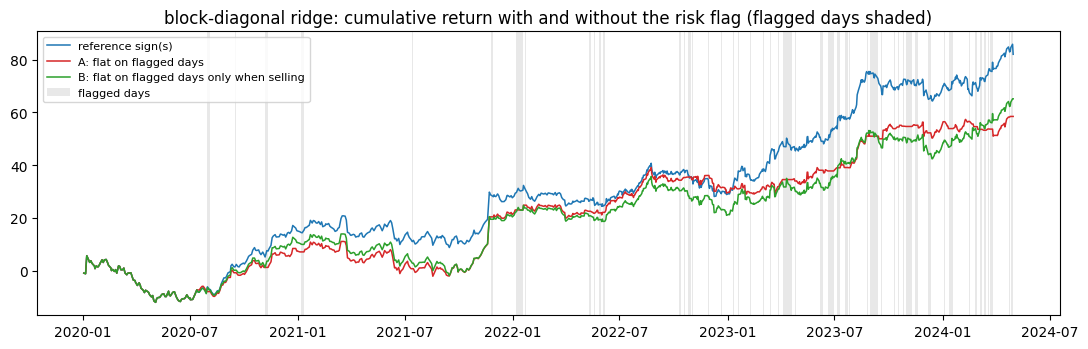

In [18]:
def rank_lag(s):
    return s.astype(float).expanding(min_periods=63).rank(pct=True).shift(1)


def tercile_flag(rk, side):
    # The rank needs 63 days of history plus the one-day lag, so it does not exist over the opening
    # stretch. Keep that as NaN rather than folding it into False: the flag is traded as False
    # there, but the placebo pool has to know which days the flag could ever have fired on.
    out = (rk > 2 / 3) if side == "top" else (rk < 1 / 3)
    return out.astype("boolean").where(rk.notna())   # nullable boolean: False is traded, NA is not eligible


# declared before any result is read; the first entry is the primary flag
FLAGS = {
    "top tercile of rank(s_{t-1}) [primary]": lambda px: tercile_flag(rank_lag(px["signal"]), "top"),
    "bottom tercile of rank(s_{t-1})": lambda px: tercile_flag(rank_lag(px["signal"]), "bottom"),
    "top tercile of rank(|s_{t-1}|)": lambda px: tercile_flag(rank_lag(px["signal"].abs()), "top"),
}

def scoreboard(r):
    r = r.astype(float)
    cum = r.cumsum()
    return pd.Series({
        "n": len(r), "mean": float(r.mean()),
        "Sharpe_ann": float(r.mean() / r.std(ddof=1) * np.sqrt(252)),
        "vol_ann": float(r.std(ddof=1) * np.sqrt(252)),
        "worst_day": float(r.min()),
        "maxDD_pts": float((cum - cum.cummax()).min()),   # cumulative-sum drawdown, return points
        "ex_kurt": float(r.kurt()),
    })

def sharpe(a):
    a = np.asarray(a, float)
    return float(a.mean() / a.std(ddof=1) * np.sqrt(252))

def boot_dsharpe(a, b, B=2000):
    # circular moving-block bootstrap, paired on the same indices (the §13 helper);
    # returns the percentile interval and the basic interval on the Sharpe change
    a = np.asarray(a, float); b = np.asarray(b, float)
    idx = _cmb_idx(len(a), B, np.random.default_rng(0))
    out = _sharpe(a[idx], axis=1) - _sharpe(b[idx], axis=1)
    lo, hi = np.percentile(out, [2.5, 97.5])
    blo, bhi = _basic(float(_sharpe(a) - _sharpe(b)), lo, hi)
    return lo, hi, blo, bhi

def apply_rules(px, flag):
    ref = px["pos"] * px["R"]
    sell = px["pos"] < 0
    return {
        "reference sign(s)": ref,
        "A: flat on flagged days": ref.where(~flag, 0.0),
        "B: flat on flagged days only when selling": ref.where(~(flag & sell), 0.0),
        "reference always-short": -px["R"],
        "A on always-short": (-px["R"]).where(~flag, 0.0),
    }

def placebo_flags(flag, elig, mode, B=2000, seed=0):
    # The flag is structurally False before the rank exists (63 days of history plus the one-day
    # lag), so a placebo drawn from all days can put flagged days where the real flag could never
    # be. Both placebo families are therefore drawn from the eligible days only.
    #   'shift': every circular shift of the flag WITHIN the eligible block (count-, run-length-
    #            and warm-up-exact);
    #   'subset': count-matched random subsets of the eligible days (the looser draw, second line)
    f0 = np.asarray(flag, bool); el = np.asarray(elig, bool); n = len(f0)
    assert not f0[~el].any(), "the flag is True on a day it cannot be evaluated on"
    e_idx = np.flatnonzero(el); m = len(e_idx); k = int(f0.sum())
    fe = f0[e_idx]
    if mode == "shift":
        out = []
        for s in range(1, m):
            f = np.zeros(n, bool); f[e_idx] = np.roll(fe, s); out.append(f)
        return out
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(B):
        f = np.zeros(n, bool); f[rng.choice(e_idx, k, replace=False)] = True
        out.append(f)
    return out

def placebo(px, flag, elig, mode="shift", B=2000):
    # placebo flags of the chosen kind; rule A and rule B analogues of (worst day, maxDD_pts, Sharpe) changes
    R = px["R"].to_numpy(float); pos = px["pos"].to_numpy(float); ref = pos * R
    sell = pos < 0
    def stats(r):
        cum = np.cumsum(r)
        return r.min(), (cum - np.maximum.accumulate(cum)).min(), sharpe(r)
    ref_w, ref_dd, ref_sh = stats(ref)
    flags = placebo_flags(flag, elig, mode, B)
    rows = {"A": np.empty((len(flags), 3)), "B": np.empty((len(flags), 3))}
    for i, f in enumerate(flags):
        ra = np.where(f, 0.0, ref); rb = np.where(f & sell, 0.0, ref)
        for key, r in (("A", ra), ("B", rb)):
            w, dd, sh = stats(r)
            rows[key][i] = (w - ref_w, dd - ref_dd, sh - ref_sh)
    return rows, (ref_w, ref_dd, ref_sh)

def pct_rank(sample, x):
    # mid-rank percentile: ties count half, so a change that no placebo touches does not read as a win
    sample = np.asarray(sample, float)
    return 50.0 * (float((sample < x).mean()) + float((sample <= x).mean()))

def tie_share(sample, x):
    return 100.0 * float((np.asarray(sample, float) == x).mean())

# ---- causality gate (flags read only s up to t-1; R never enters the flag) ----
px0 = books["blk2"].loc[common]
prim = list(FLAGS)[0]
rng_g = np.random.default_rng(0)
for t in rng_g.choice(np.arange(70, len(px0) - 1), 10, replace=False):
    base = FLAGS[prim](px0).fillna(False).astype(bool).to_numpy()
    p1 = px0.copy(); p1.loc[p1.index[t:], "R"] *= 3.0
    p2 = px0.copy(); p2.loc[p2.index[t:], "signal"] *= 3.0
    f1 = FLAGS[prim](p1).fillna(False).astype(bool).to_numpy()
    f2 = FLAGS[prim](p2).fillna(False).astype(bool).to_numpy()
    assert (f1[: t + 1] == base[: t + 1]).all() and (f2[: t + 1] == base[: t + 1]).all()
print("causality: flags for days <= t unchanged by perturbing R or s on days >= t (10 draws)")

# ---- reference gate: against the deck's regenerated outputs on the current frame, never a literal ----
ref0 = px0["pos"] * px0["R"]
print(f"reference sign(s), block-diagonal ridge: n {len(ref0)} mean {ref0.mean():.4f} Sharpe {sharpe(ref0):.3f}")
_dev15 = float((deck_ref.reindex(ref0.index) - ref0).abs().max())
assert deck_ref.reindex(ref0.index).notna().all(), "a common day is missing from daily_blk2.parquet"
_rt15 = pd.read_csv(OUT / "rule_table_blk2.csv", index_col=0)
_dm15 = abs(float(ref0.mean()) - float(_rt15.loc["sign(s)", "mean"]))
_ds15 = abs(sharpe(ref0) - float(_rt15.loc["sign(s)", "Sharpe_ann"]))
print(f"gate: against the deck's regenerated outputs, max |daily difference| {_dev15:.2e}, "
      f"|mean difference| {_dm15:.2e}, |Sharpe difference| {_ds15:.2e} (quote rounding)")
assert len(ref0) == int(_rt15.loc["sign(s)", "n"])
assert _dev15 < 1e-5 and _dm15 < 1e-7 and _ds15 < 1e-6

# ---- the three 'plain sign(s)' references in this notebook must be the same portfolio ----
_gates = {
    "S12 lambda=0, quoted subset": set(idx_s),
    "S14 plain leg, credit>0 days": set(gate14_days),
    "S15 reference, all common days": set(px0.index),
}
_sh = {
    "S12 lambda=0, quoted subset": float(tc_tabs["straddle"].loc[("lam=0.0", "sign(s)"), "Sharpe_ann"]),
    "S14 plain leg, credit>0 days": gate14_plain_sharpe,
    "S15 reference, all common days": sharpe(ref0),
}
print("plain sign(s), the three gates in this notebook:")
for _k in _gates:
    print(f"  {_k:34s} n={len(_gates[_k]):4d}  Sharpe {_sh[_k]:.4f}")
_base = _gates["S15 reference, all common days"]
for _k, _v in _gates.items():
    assert _v == _base, (_k, sorted(str(d.date()) for d in _base ^ _v))
assert max(_sh.values()) - min(_sh.values()) < 1e-8, _sh
print("  the three gates score the same days and agree to 1e-8")

# ---- where the reference drawdown sits ----
_cum0 = ref0.cumsum(); _dd0 = _cum0 - _cum0.cummax()
_tr0 = _dd0.idxmin(); _pk0 = _cum0.loc[:_tr0].idxmax()
_elig0 = FLAGS[prim](px0).notna()
_pre0 = int((~_elig0).sum())
print(f"reference maximum drawdown {float(_dd0.min()):+.3f} points, peak {_pk0.date()} trough {_tr0.date()}; "
      f"the flag is undefined on the first {_pre0} sessions (the rank needs 63 days of history plus the "
      f"one-day lag), so every placebo below is drawn from the {int(_elig0.sum())} eligible days only.")
print(f"  the drawdown opens on day {int(px0.index.get_loc(_pk0)) + 1} of {len(px0)} and closes on day "
      f"{int(px0.index.get_loc(_tr0)) + 1}, so it overlaps that ineligible span: read placebo_pct_maxDD_pts "
      "beside tie_pct_maxDD_pts, because a placebo that puts no flagged day inside the drawdown window "
      "leaves the drawdown exactly unchanged and those ties carry most of the distribution.")

# ---- scoreboards, all models, all flags ----
rows = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    for fname, fn in FLAGS.items():
        flag = fn(px).fillna(False).astype(bool)
        for rname, r in apply_rules(px, flag).items():
            s = scoreboard(r)
            s["flagged_days"] = int(flag.sum())
            s["flagged_sell_days"] = int((flag & (px["pos"] < 0)).sum())
            rows[(fname, rname, tag)] = s
tab = pd.DataFrame(rows).T
tab.index = pd.MultiIndex.from_tuples(tab.index, names=["flag", "rule", "model"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag)
    tab.xs(tag, level="model").to_csv(OUT / f"riskflag_summary_{safe}.csv")
print("saved riskflag_summary_<model>.csv in", OUT)

# does the flag reach the tail for ANY model? one row per (model, flag, rule) against its own reference
_cells = []
for (fname, rname, tag), row in tab.iterrows():
    if rname not in ("A: flat on flagged days", "B: flat on flagged days only when selling"):
        continue
    ref = tab.loc[(fname, "reference sign(s)", tag)]
    _cells.append((float(row["worst_day"]) - float(ref["worst_day"]),
                   float(row["maxDD_pts"]) - float(ref["maxDD_pts"])))
_dw = np.array([c[0] for c in _cells])
_dd = np.array([c[1] for c in _cells])
print(f"across {len(MODEL_ORDER)} forecasts x {len(FLAGS)} flags x 2 rules = {len(_cells)} cells: "
      f"worst day unchanged in {int((np.abs(_dw) < 1e-9).sum())}, "
      f"maximum drawdown unchanged in {int((np.abs(_dd) < 1e-9).sum())}; "
      f"drawdown changes span {_dd.min():+.2f} to {_dd.max():+.2f} points")

px = books["blk2"].loc[common]
MAIN = ("reference sign(s)", "A: flat on flagged days", "B: flat on flagged days only when selling")
for fname in FLAGS:
    raw = FLAGS[fname](px)
    flag = raw.fillna(False).astype(bool)
    elig = raw.notna().to_numpy()
    print(f"\n=== flag: {fname} --- block-diagonal ridge, {len(px)} days, {int(elig.sum())} eligible ===")
    sub = tab.xs(fname, level="flag").xs("blk2", level="model")
    print(sub.to_string(float_format=lambda x: f"{x:+.4f}"))
    rr = px["pos"] * px["R"]
    print("what the flag bought: mean return on flagged days {:+.4f} vs unflagged {:+.4f}; mean |R| flagged {:.4f} vs unflagged {:.4f}; "
          "flagged {} days, of which {} sells".format(
              rr[flag].mean(), rr[~flag].mean(), px["R"].abs()[flag].mean(), px["R"].abs()[~flag].mean(),
              int(flag.sum()), int((flag & (px["pos"] < 0)).sum())))
    rules = apply_rules(px, flag)
    per_year = pd.DataFrame({k: rules[k].groupby(rules[k].index.year).min() for k in MAIN})
    print("per-year worst day:")
    print(per_year.to_string(float_format=lambda x: f"{x:+.3f}"))
    ref = rules[MAIN[0]]
    plc, (rw, rdd, rsh) = placebo(px, flag, elig, "shift")
    plc_sub, _ = placebo(px, flag, elig, "subset")
    n_shift = plc["A"].shape[0]
    pair_rows = []
    for key, rname in (("A", MAIN[1]), ("B", MAIN[2])):
        r = rules[rname]; d = r - ref
        t, lag = hac_t(d); lo, hi, blo, bhi = boot_dsharpe(r, ref)
        real = (float(r.min() - rw), float((r.cumsum() - r.cumsum().cummax()).min() - rdd), sharpe(r) - rsh)
        pcts = [pct_rank(plc[key][:, j], real[j]) for j in range(3)]
        ties = [tie_share(plc[key][:, j], real[j]) for j in range(3)]
        pcts_sub = [pct_rank(plc_sub[key][:, j], real[j]) for j in range(3)]
        pair_rows.append({"rule": rname, "mean_delta": float(d.mean()), "HAC_t": t, "hac_lag": lag,
                          "dSharpe": real[2], "boot_lo": lo, "boot_hi": hi, "boot_basic_lo": blo, "boot_basic_hi": bhi,
                          "verdict_dSharpe": _verdict(lo, hi),
                          "worst_day_change": real[0], "maxDD_pts_change": real[1],
                          # the drawdown percentile is a tie-heavy read: most placebos leave the
                          # drawdown untouched, so it is reported with its tie share, never alone
                          "placebo_pct_worst": pcts[0], "placebo_pct_maxDD_pts": pcts[1],
                          "placebo_pct_dSharpe": pcts[2],
                          "tie_pct_worst": ties[0], "tie_pct_maxDD_pts": ties[1], "tie_pct_dSharpe": ties[2],
                          "subset_pct_worst": pcts_sub[0], "subset_pct_maxDD_pts": pcts_sub[1],
                          "subset_pct_dSharpe": pcts_sub[2]})
    pr = pd.DataFrame(pair_rows).set_index("rule")
    print("paired against the reference (HAC t on the daily difference, Bartlett kernel; circular block-bootstrap 95% percentile and basic intervals on the Sharpe change)")
    print(f"placebo percentiles (mid-rank, ties count half): where the realized change sits among all {n_shift} circular shifts of the real flag within the eligible days;")
    print("tie_pct_* is the share of shifts that leave the statistic exactly unchanged; subset_pct_* repeats the read against 2000 count-matched random draws from the eligible days:")
    print(pr.to_string(float_format=lambda x: f"{x:+.3f}"))
    if fname == prim:
        pr.to_csv(OUT / "riskflag_paired_blk2.csv")

# ---- where the sell-side losses live, and what the primary flag sacrifices ----
flag = FLAGS[prim](px).fillna(False).astype(bool)
rk = rank_lag(px["signal"])
ref = px["pos"] * px["R"]
sell = px["pos"] < 0
terc = pd.cut(rk, [0.0, 1 / 3, 2 / 3, 1.0], labels=["bottom", "middle", "top"], include_lowest=True)
trows = []
for name in ("bottom", "middle", "top"):
    in_t = terc == name
    m = sell & in_t
    trows.append({"tercile of rank(s_{t-1})": name, "days": int(in_t.sum()),
                  "share that are sell days": float(sell[in_t].mean()),
                  "sell days": int(m.sum()), "mean |R| on sell days": float(px["R"].abs()[m].mean()),
                  "worst sell-day return": float(ref[m].min()), "sell days below -2": int((ref[m] < -2).sum())})
tterc = pd.DataFrame(trows).set_index("tercile of rank(s_{t-1})")
print("\nsell days by tercile of the lagged rank (the top tercile is the primary flag):")
print(tterc.to_string(float_format=lambda x: f"{x:+.3f}"))
tterc.to_csv(OUT / "riskflag_sell_terciles_blk2.csv")

worst10 = ref.nsmallest(10)
share_ret = float(ref[flag].sum() / ref.sum())
share_loss = float(worst10[flag.reindex(worst10.index)].sum() / worst10.sum())
w10_mask = ref.index.isin(worst10.index)
plc_flags = placebo_flags(flag.to_numpy(), FLAGS[prim](px).notna().to_numpy(), "shift")
plc_share = np.array([ref.to_numpy()[f & w10_mask].sum() / worst10.sum() for f in plc_flags])
print(f"sacrifice versus protection: flagged days carry {100 * share_ret:.1f}% of the reference return "
      f"but only {100 * share_loss:.1f}% of the ten worst days' losses; "
      f"placebo mid-rank percentile of that loss share {pct_rank(plc_share, share_loss):.0f} among all {len(plc_flags)} circular shifts of the flag within the eligible days "
      f"(tie share {tie_share(plc_share, share_loss):.0f}%; shifted flags cover more of the worst days' losses than this flag on "
      f"{100 * float((plc_share > share_loss).mean()):.0f}% of shifts)")
print(f"worst day flagged: sign(s) {bool(flag.loc[ref.idxmin()])}, always-short {bool(flag.loc[(-px['R']).idxmin()])}")
absflag = (rank_lag(px["R"].abs()) > 2 / 3).fillna(False).astype(bool)
print("a no-forecast comparator, the top tercile of yesterday's realized |R|: mean |R| on flagged days "
      f"{px['R'].abs()[absflag].mean():.3f} vs unflagged {px['R'].abs()[~absflag].mean():.3f} "
      f"(the lagged-signal flag: {px['R'].abs()[flag].mean():.3f} vs {px['R'].abs()[~flag].mean():.3f})")

flag = FLAGS[prim](px).fillna(False).astype(bool)
rules = apply_rules(px, flag)
fig, ax = plt.subplots(figsize=(11, 3.6))
for k, c in zip(MAIN, ("C0", "C3", "C2")):
    ax.plot(px.index, rules[k].cumsum().values, lw=1.1, color=c, label=k)
lo_y, hi_y = ax.get_ylim()
ax.fill_between(px.index, lo_y, hi_y, where=flag.to_numpy(), color="0.85", alpha=0.6, lw=0, label="flagged days")
ax.set_ylim(lo_y, hi_y)
ax.set_title("block-diagonal ridge: cumulative return with and without the risk flag (flagged days shaded)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "riskflag_cum_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "riskflag_cum_blk2.png")
display(fig)
plt.close(fig)


## 16. The body itself: a same-strike straddle against the nearest out-of-the-money pair

Every portfolio in the deck is built on the same package: the nearest
out-of-the-money call (smallest listed strike at or above the 15:30
index level) and the nearest out-of-the-money put (largest strike at or
below it). SPX strikes sit five points apart and the index almost never
lands on one, so that package is a five-point-wide strangle on more
than 99% of days (the two strikes coincide on about 0.1% of days, and
sit ten apart on about 0.5% when a strike lacks quotes). This section
asks what changes if the body is instead a true straddle: both legs at
the single listed strike nearest to the index level, with live quotes
on both legs (an exact tie goes to the lower strike). The signal and
the position rules are unchanged; only the instrument differs. Both
bodies are settled in cash against the official close on the same
days.

**Three ways to measure the same dollars.** The two bodies differ by
one thing, and it can be written down. If the straddle strike is the
lower of the strangle's two strikes, straddle = strangle + a long
five-point call spread between them; if it is the upper strike,
straddle = strangle + a long five-point put spread. The cell verifies
this identity day by day from the leg quotes and then reports each
portfolio in three frames: per dollar of premium (the deck's unit), per
dollar of **time value**, and in index points per package. The
time-value frame matters here because the straddle's premium contains
intrinsic value — the distance from the index level to its strike,
known at entry — that the strangle's premium does not; dividing by
total premium therefore dilutes the straddle's returns relative to
the strangle's by construction. The strangle's premium is all time
value, so its per-premium and per-time-value figures coincide. A
comparison across bodies is like-for-like only in the time-value frame
or in points.

Also reported: where the index sits on the strike grid — the offset
$|S-K^*|$ is at most half the five-point strike spacing whenever the
nearest strike is quoted on both legs, and larger on the rare day when
it is not, so the bound is a property of the grid rather than a
guarantee; the cell prints the median, the maximum, and the share of
days inside 2.5 points — and both bodies' $\mathrm{sign}(s)$
results by tercile of that offset; the five-point vertical on its own —
its mean, its HAC $t$, and its share of the straddle's daily
variance — which decides whether the extra premium is edge or fairly
priced risk; crossed-spread fills (sell at the bid, buy at the ask, on every
leg, with the in-the-money leg's relative spread printed against the
others); and the estimated-fraction rule (parked in the main
notebook: expanding mean over second moment with a running ruin cap,
minimum 63 days, lagged one day) on the $\mathrm{sign}(s)$ portfolio in the
two return frames.

**What the numbers say.** In dollars the two $\mathrm{sign}(s)$ portfolios are the
same portfolio: about 0.22 index points per package-day each, a
difference of about a hundredth of a point a day, and the same worst
day to within the strike gap (−78.4 points for the strangle against
−80.0 for the straddle). The extra premium the straddle collects — a
median 7.68 points against 5.39, of which about 1.41 is intrinsic and
6.39 time value — is the five-point vertical, and the vertical is
fairly priced risk rather than edge: sold on its own it earns about
0.11 points per day with a $t$ of about 1.4, carries about 7% of the
straddle's daily variance, is essentially uncorrelated with the
strangle ($-0.05$), and the $\mathrm{sign}(s)$ rule has nothing to say
about it (about $-0.01$ points per day, $t$ near zero). It is a
small directional bet on which side of the strike the index closes;
the variance forecast does not inform it.

The frames then re-scale that one dollar P&L in three ways, and the
choice of denominator produces every apparent difference. Per dollar
of premium the straddle looks worse on the $\mathrm{sign}(s)$ rule — Sharpe
about 1.19 against 1.34, a mean lower by about 0.035 per day with a
HAC $t$ near −2.2 — and its worst day looks shorter (about −3.2
against −5.4). Both are the intrinsic value in the denominator: the
same dollar loss divided by a larger, partly riskless premium; and the
sign of the Sharpe change is not even uniform across the eight
forecast tables (four gain, four lose, none by more than 0.15), which is
itself the signature of a denominator effect rather than an edge. Per
dollar of time value, the like-for-like frame, the two bodies are
indistinguishable — Sharpe about 1.35 against 1.34 for the
block-diagonal ridge, a paired $t$ near −0.5, and a change between
$-0.005$ and $+0.147$ across the eight forecast tables (seven gain,
one a hair negative) — and the worst day is about
−4.1 against −5.4, a smaller gap that again reflects the denominator
(the straddle's time value exceeds the strangle's premium by about a
point on a typical day). The always-short control gains in every frame
(0.50 and 0.35 against 0.20 per premium and per time value, 0.25
against 0.04 in points), but that gain is the vertical's 0.11 points
per day, which is not significant.

The estimated-fraction rule sees the same thing: its fraction is
about 0.050 to 0.054 for either body in either frame. Because the
fraction is applied to the scaled return, each frame is a different
position-sizing rule on the same instrument — the per-time-value
straddle path holds more packages on days when time value is small —
and the terminal-wealth differences (about ×8 for the strangle, ×4
for the straddle per premium, ×8 per time value) are those sizing
rules, not a difference in edge. Where the index sits on the strike
grid does not separate the bodies either: both lose a little in the
third of days on which the index sits closest to a listed strike
(Sharpe about −0.23 and −0.27) and both earn about the same as each other
in the other two thirds — a property of those days, not of either body.
Crossed-spread fills favour the strangle: the straddle's legs are not
wider in relative terms (about 5.1% and 5.5% of mid against 5.9%), but
its package spread is larger in points and its per-premium returns
smaller, so after crossing the spread on every leg the
$\mathrm{sign}(s)$ portfolio scores about 0.60 against 0.87 per premium
(about 0.75 against 0.87 per time value, where the crossed-spread
return is measured against the *filled* time value, not the midpoint one), and
always-short is negative for both.

**Verdict.** The same-strike straddle is not a tail fix. The shorter
per-premium worst day is intrinsic value in the denominator, the dollar
P&L is identical, and the difference between the bodies is a fairly
priced five-point vertical that the signal cannot time and that costs
more to cross. The strangle body stays: it is all time value, so its
per-premium figures are already the like-for-like ones, and it is
cheaper to fill. The compensation for the strike not sitting at the
index level is not a different instrument but a different denominator
— measure returns on time value, which is what the strangle's premium
already is. On XSP, where strikes are one point apart (ten SPX
points), the same construction would have a ten-point gap and the
question would have to be asked again.

time value <= 0 on 0 day(s), dropped: []
offset |S - K*|: median 1.36, max 4.96 points (half the 5-point strike spacing on 99.92% of days; a larger offset means the nearest strike had no two-sided quote on both legs)
the deck's body on the common days: gap between the two strikes (points), share of days
0.000000      0.120000
5.000000     99.420000
10.000000     0.460000
days scored: 866 of 866 common days have a same-strike straddle with live quotes on both legs
straddle strike is one of the strangle's two strikes on 100.0% of scored days; the call is the in-the-money leg on 52.0%
gate: strangle rows reproduce rule_table_blk2 (always short and sign(s) means) exactly


--- block-diagonal ridge: the two bodies in three frames ---
premium, median points: strangle 5.39, straddle 7.68 (of which intrinsic 1.41, time value 6.39)
the strangle expires worthless on 22.3% of days; the straddle settles within 1 point of its strike on 8.8%
[per premium]
                                            mean  Sharpe  worst_day  maxDD_pts
body                        rule                                              
strangle (nearest OTM pair) always short +0.0145 +0.2038   -10.3160   -19.2945
                            sign(s)      +0.0947 +1.3383    -5.4225   -17.7022
straddle (same strike)      always short +0.0251 +0.5000    -5.6179   -19.0719
                            sign(s)      +0.0595 +1.1886    -3.2255   -13.2714
[per time value]
                                            mean  Sharpe  worst_day  maxDD_pts
body                        rule                                              
strangle (nearest OTM pair) always short +0.0145 +0.2038   -10.3160   -19

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\body_lab_cum_blk2.png


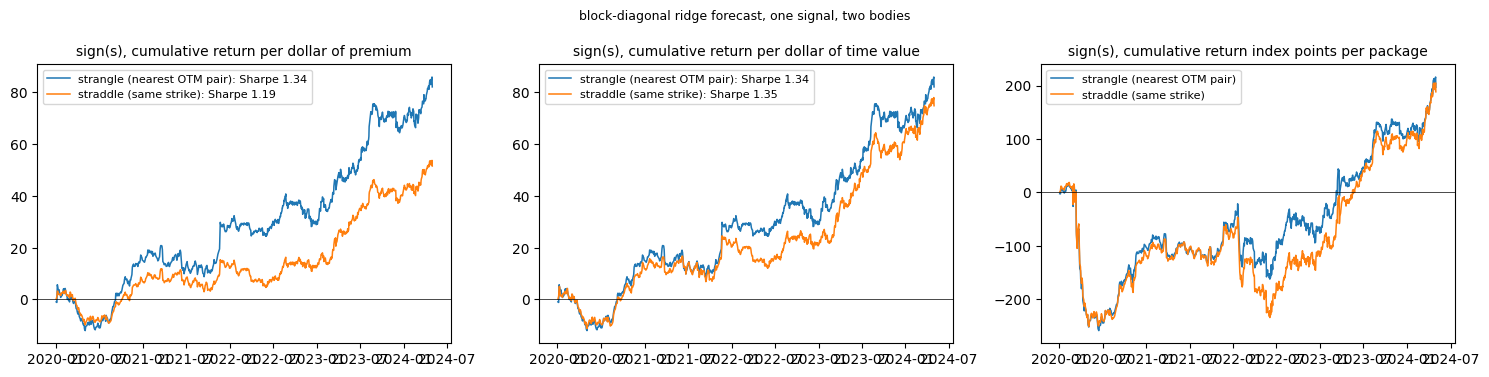

In [19]:
# --- the two bodies -----------------------------------------------------------
# strangle body: the deck's nearest out-of-the-money call and put (books[tag] carries it)
# straddle body: call and put at the single listed strike nearest to the 15:30 index level
_c = live[live["cp"] == "C"][["expiration", "strike", "bid", "ask", "mid"]].rename(
    columns={"bid": "bid_c", "ask": "ask_c", "mid": "mid_c"})
_p = live[live["cp"] == "P"][["expiration", "strike", "bid", "ask", "mid"]].rename(
    columns={"bid": "bid_p", "ask": "ask_p", "mid": "mid_p"})
_both = _c.merge(_p, on=["expiration", "strike"])
_both["strike"] = _both["strike"].astype(float)
_both["S"] = _both["expiration"].map(spot).astype(float)
_both = _both[np.isfinite(_both["S"])]
_both["dist"] = (_both["strike"] - _both["S"]).abs()
# nearest strike with live quotes on both legs; an exact tie goes to the lower strike
strad = _both.sort_values(["expiration", "dist", "strike"]).groupby("expiration", as_index=False).first()
_emap = atm.reset_index()[["day", "expiration", "S_close", "K_c", "K_p", "mid_c", "mid_p"]].rename(
    columns={"mid_c": "sg_mid_c", "mid_p": "sg_mid_p"})
strad = strad.merge(_emap, on="expiration", how="inner").set_index("day").sort_index()
strad["K"] = strad["strike"]
strad["entry"] = strad["mid_c"] + strad["mid_p"]
strad["exit"] = (strad["S_close"] - strad["K"]).abs()
strad = strad[np.isfinite(strad["entry"]) & (strad["entry"] > 0) & np.isfinite(strad["exit"])].copy()
strad["R"] = strad["exit"] / strad["entry"] - 1.0
strad["offset"] = strad["dist"]                       # |S - K*|, the intrinsic value at entry
strad["time_value"] = strad["entry"] - strad["offset"]
# a package cannot be worth less than its intrinsic value: a non-positive time value is a stale or
# frozen quote, and dividing by it would flip the sign of the return
_tv_bad = strad.index[~(strad["time_value"] > 0)]
print(f"time value <= 0 on {len(_tv_bad)} day(s), dropped:", [str(d.date()) for d in _tv_bad])
strad = strad[strad["time_value"] > 0].copy()
print(f"offset |S - K*|: median {float(strad['offset'].median()):.2f}, max {float(strad['offset'].max()):.2f} points "
      f"(half the 5-point strike spacing on {float((strad['offset'] <= 2.5 + 1e-9).mean()):.2%} of days; "
      "a larger offset means the nearest strike had no two-sided quote on both legs)")
strad["itm_leg"] = np.where(strad["S"] >= strad["K"], "call", "put")
# the 5-point vertical that turns the strangle into the straddle:
#   K* = K_p -> long call spread K_p/K_c ; K* = K_c -> long put spread K_c/K_p
_on_grid = (strad["K"] == strad["K_p"]) | (strad["K"] == strad["K_c"])
_is_low = strad["K"] == strad["K_p"]
strad["vert_entry"] = np.where(_is_low, strad["mid_c"] - strad["sg_mid_c"], strad["mid_p"] - strad["sg_mid_p"])
strad["vert_exit"] = np.where(
    _is_low,
    np.maximum(strad["S_close"] - strad["K_p"], 0.0) - np.maximum(strad["S_close"] - strad["K_c"], 0.0),
    np.maximum(strad["K_c"] - strad["S_close"], 0.0) - np.maximum(strad["K_p"] - strad["S_close"], 0.0),
)
strad.loc[~_on_grid, ["vert_entry", "vert_exit"]] = np.nan

gap = (atm.loc[common, "K_c"] - atm.loc[common, "K_p"]).round(2)
print("the deck's body on the common days: gap between the two strikes (points), share of days")
print((gap.value_counts(normalize=True).sort_index() * 100).round(2).to_string())
days = common.intersection(strad.index)
print(f"days scored: {len(days)} of {len(common)} common days have a same-strike straddle with live quotes on both legs")
print(f"straddle strike is one of the strangle's two strikes on {float(_on_grid.loc[days].mean()):.1%} of scored days; "
      f"the call is the in-the-money leg on {float((strad.loc[days, 'itm_leg'] == 'call').mean()):.1%}")


def bl_sharpe(a):
    a = np.asarray(a, float)
    return float(a.mean() / a.std(ddof=1) * np.sqrt(252))


def bl_hac(d):
    d = np.asarray(d, float)
    lag = int(np.floor(1.5 * len(d) ** (1 / 3)))
    f = sm.OLS(d, np.ones((len(d), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    return float(f.params[0]), float(f.tvalues[0]), lag


def bl_boot(a, b, B=2000):
    # circular moving-block bootstrap, paired on the same indices (the §13 helper): percentile and basic intervals
    a = np.asarray(a, float); b = np.asarray(b, float)
    idx = _cmb_idx(len(a), B, np.random.default_rng(0))
    out = _sharpe(a[idx], axis=1) - _sharpe(b[idx], axis=1)
    lo, hi = np.percentile(out, [2.5, 97.5])
    blo, bhi = _basic(float(_sharpe(a) - _sharpe(b)), lo, hi)
    return lo, hi, blo, bhi


def bl_kelly(rs):
    mu = rs.expanding(min_periods=63).mean().shift(1)
    m2 = (rs**2).expanding(min_periods=63).mean().shift(1)
    cap = 1.0 / rs.expanding(min_periods=1).min().shift(1).abs()
    return np.minimum((mu / m2).clip(lower=0.0), cap).fillna(0.0)


def bl_wealth(f, r):
    fac = 1.0 + np.asarray(f, float) * np.asarray(r, float)
    assert (fac > 0).all()
    w = np.cumprod(fac)
    return {"g_ann": 252.0 * float(np.mean(np.log(fac))), "terminal": float(w[-1]),
            "maxDD_frac": float((w / np.maximum.accumulate(w) - 1.0).min()),   # wealth, fraction of peak
            "worst_day_factor": float(fac.min())}


def bl_row(rp):
    cum = rp.cumsum()
    return {"mean": float(rp.mean()), "Sharpe": bl_sharpe(rp), "worst_day": float(rp.min()),
            "maxDD_pts": float((cum - cum.cummax()).min())}   # cumulative-sum drawdown, return points


# gate: the strangle rows must reproduce the published rule table before anything is compared
_rt = pd.read_csv(OUT / "rule_table_blk2.csv", index_col=0)
_pxg = books["blk2"].loc[common]
assert abs(float((-_pxg["R"]).mean()) - float(_rt.loc["always short", "mean"])) < 1e-9
assert abs(float((_pxg["pos"] * _pxg["R"]).mean()) - float(_rt.loc["sign(s)", "mean"])) < 1e-9
print("gate: strangle rows reproduce rule_table_blk2 (always short and sign(s) means) exactly")

BODIES = ("strangle (nearest OTM pair)", "straddle (same strike)")
RULES = ("always short", "sign(s)")
FRAMES = ("per premium", "per time value", "index points")
score, paired, kelly_rows = {}, {}, {}
for tag in MODEL_ORDER:
    px = books[tag].loc[days]
    st = strad.loc[days]
    # three frames: per dollar of premium, per dollar of time value, index points per package
    frames = {
        BODIES[0]: {"per premium": px["R"], "per time value": px["R"], "index points": px["exit"] - px["entry"]},
        BODIES[1]: {"per premium": st["R"], "per time value": (st["exit"] - st["entry"]) / st["time_value"],
                    "index points": st["exit"] - st["entry"]},
    }
    q = {"always short": pd.Series(-1.0, index=days), "sign(s)": px["pos"].astype(float)}
    rp = {}
    for b in BODIES:
        for rule, qq in q.items():
            for fr in FRAMES:
                rp[(b, rule, fr)] = qq * frames[b][fr]
                row = bl_row(qq * frames[b][fr])
                row["n"] = int(len(days))
                row["premium_median"] = float((px if b == BODIES[0] else st)["entry"].median())
                row["pin_share"] = float(((px if b == BODIES[0] else st)["R"] <= -0.999).mean())
                score[(LABEL[tag], b, rule, fr)] = row
    for rule in RULES:
        for fr in ("per premium", "per time value"):
            a, b_ = rp[(BODIES[1], rule, fr)], rp[(BODIES[0], rule, fr)]
            m, t, lag = bl_hac(a - b_)
            lo, hi, blo, bhi = bl_boot(a, b_)
            paired[(LABEL[tag], rule, fr)] = {"mean_diff": m, "HAC_t": t, "lag": lag,
                                              "dSharpe": bl_sharpe(a) - bl_sharpe(b_), "dSharpe_lo": lo, "dSharpe_hi": hi,
                                              "dSharpe_basic_lo": blo, "dSharpe_basic_hi": bhi,
                                              "verdict_dSharpe": _verdict(lo, hi)}
    for b in BODIES:
        for fr in ("per premium", "per time value"):
            r = rp[(b, "sign(s)", fr)]
            fk = bl_kelly(r)
            row = {"mean_f": float(fk.mean()), **bl_wealth(fk, r)}
            half = bl_wealth(fk / 2, r)
            row["half_terminal"] = half["terminal"]; row["half_worst_day_factor"] = half["worst_day_factor"]
            kelly_rows[(LABEL[tag], b, fr)] = row
    if tag == "blk2":
        blk2_rp, blk2_px, blk2_st = rp, px, st

score_tab = pd.DataFrame(score).T
score_tab.index = pd.MultiIndex.from_tuples(score_tab.index, names=["model", "body", "rule", "frame"])
score_tab.to_csv(OUT / "body_lab_scoreboard.csv")
paired_tab = pd.DataFrame(paired).T
paired_tab.index = pd.MultiIndex.from_tuples(paired_tab.index, names=["model", "rule", "frame"])
paired_tab.to_csv(OUT / "body_lab_paired.csv")
kelly_tab = pd.DataFrame(kelly_rows).T
kelly_tab.index = pd.MultiIndex.from_tuples(kelly_tab.index, names=["model", "body", "frame"])
kelly_tab.to_csv(OUT / "body_lab_kelly.csv")

px, st = blk2_px, blk2_st
print("--- block-diagonal ridge: the two bodies in three frames ---")
print(f"premium, median points: strangle {float(px['entry'].median()):.2f}, straddle {float(st['entry'].median()):.2f} "
      f"(of which intrinsic {float(st['offset'].median()):.2f}, time value {float(st['time_value'].median()):.2f})")
print(f"the strangle expires worthless on {float((px['R'] <= -0.999).mean()):.1%} of days; "
      f"the straddle settles within 1 point of its strike on {float((st['exit'] < 1.0).mean()):.1%}")
for fr in FRAMES:
    print(f"[{fr}]")
    print(score_tab.xs((LABEL["blk2"], fr), level=("model", "frame"))[["mean", "Sharpe", "worst_day", "maxDD_pts"]]
          .to_string(float_format=lambda x: f"{x:+.4f}"))
print("--- paired daily difference, straddle minus strangle, block-diagonal ridge ---")
print(paired_tab.xs(LABEL["blk2"], level="model").to_string(float_format=lambda x: f"{x:+.3f}"))
print(f"--- all {len(MODEL_ORDER)} forecasts: change in Sharpe from switching to the straddle body ---")
print(paired_tab["dSharpe"].unstack(["rule", "frame"]).to_string(float_format=lambda x: f"{x:+.3f}"))

# per-year Sharpe, both bodies, both rules, per premium and per time value
per_year = pd.DataFrame({(b, rule, fr): blk2_rp[(b, rule, fr)].groupby(blk2_rp[(b, rule, fr)].index.year).apply(bl_sharpe)
                         for b in BODIES for rule in RULES for fr in ("per premium", "per time value")})
per_year.columns = pd.MultiIndex.from_tuples(per_year.columns, names=["body", "rule", "frame"])
per_year.to_csv(OUT / "body_lab_per_year_blk2.csv")
print("--- per-year Sharpe, block-diagonal ridge, sign(s) ---")
print(per_year.xs("sign(s)", level="rule", axis=1).to_string(float_format=lambda x: f"{x:+.2f}"))

# where spot sits on the strike grid: does the straddle's result depend on it?
off = st["offset"]
print("--- offset |S - K*| at entry: median "
      f"{float(off.median()):.2f} points; above 1.25 on {float((off > 1.25).mean()):.1%} of days ---")
terc = pd.qcut(off, 3, labels=["near the strike", "middle", "far from the strike"])
for fr in ("per premium", "per time value"):
    tab = {}
    for b in BODIES:
        r = blk2_rp[(b, "sign(s)", fr)]
        g = r.groupby(terc, observed=True)
        tab[(b, "n")] = g.size(); tab[(b, "mean")] = g.mean(); tab[(b, "Sharpe")] = g.apply(bl_sharpe); tab[(b, "worst")] = g.min()
    tab = pd.DataFrame(tab)
    print(f"sign(s) by tercile of the straddle's offset, both bodies on the same days [{fr}]")
    print(tab.to_string(float_format=lambda x: f"{x:+.3f}"))
    tab.to_csv(OUT / f"body_lab_offset_{fr.replace(' ', '_')}_blk2.csv")

# the identity: short straddle = short strangle + short 5-point vertical between the two strikes
grid = np.isfinite(st["vert_entry"])
strad_short = (st["entry"] - st["exit"])[grid]
sg_short = (px["entry"] - px["exit"])[grid]
vert_short = (st["vert_entry"] - st["vert_exit"])[grid]
resid = float((strad_short - sg_short - vert_short).abs().max())
print(f"--- decomposition on {int(grid.sum())} days where the straddle strike is one of the strangle's strikes; "
      f"max identity residual {resid:.2e} points ---")
m_v, t_v, lag_v = bl_hac(vert_short)
_vgap = (st.loc[grid, "K_c"] - st.loc[grid, "K_p"]).abs()
print(f"short vertical alone: mean {m_v:+.3f} points/day (HAC t {t_v:+.2f}, lag {lag_v}); "
      f"premium collected median {float(st.loc[grid, 'vert_entry'].median()):.2f} against a maximum loss equal to "
      f"the gap between the two strikes (median {float(_vgap.median()):.1f} points; "
      f"{float((_vgap != 5.0).mean()):.2%} of these days are not five points)")
print(f"variance shares of the short straddle: strangle {float(np.cov(sg_short, strad_short)[0, 1] / strad_short.var(ddof=1)):.3f}, "
      f"vertical {float(np.cov(vert_short, strad_short)[0, 1] / strad_short.var(ddof=1)):.3f}; "
      f"var(vertical)/var(straddle) {float(vert_short.var(ddof=1) / strad_short.var(ddof=1)):.3f}; "
      f"corr(vertical, strangle) {float(np.corrcoef(vert_short, sg_short)[0, 1]):+.3f}")
ls_v = (px["pos"].astype(float) * (st["vert_exit"] - st["vert_entry"]))[grid]
m_lv, t_lv, _ = bl_hac(ls_v)
print(f"the vertical under the sign(s) rule: mean {m_lv:+.3f} points/day (t {t_lv:+.2f})")
pd.DataFrame({"straddle_short_pts": strad_short, "strangle_short_pts": sg_short, "vertical_short_pts": vert_short}).to_csv(
    OUT / "body_lab_decomposition_blk2.csv")

print("--- fraction of wealth (sign(s)), all forecasts ---")
print(kelly_tab.to_string(float_format=lambda x: f"{x:+.3f}"))


# --- realistic fills: sell at the bid, buy at the ask, on every leg -----------
def _leg_ok(bid, ask, sold):
    b = pd.to_numeric(bid, errors="coerce"); a = pd.to_numeric(ask, errors="coerce")
    base = np.isfinite(b) & np.isfinite(a) & (a >= b) & (b >= 0)
    return base & (b > 0) if sold else base & (a > 0)


q_sign = px["pos"].astype(float)
ok = pd.Series(True, index=days)
for fr_ in (px, st):
    for bcol, acol in (("bid_c", "ask_c"), ("bid_p", "ask_p")):
        ok &= _leg_ok(fr_[bcol], fr_[acol], True)                       # the sold legs (always short sells both every day)
        ok &= _leg_ok(fr_[bcol], fr_[acol], False)                      # the bought legs on long days
print(f"--- crossed-spread fills: {int(ok.sum())} of {len(days)} days have usable bid/ask on all four legs of both bodies ---")
fills, spreads = {}, {}
for b, fr_ in ((BODIES[0], px), (BODIES[1], st)):
    bid_sum = fr_["bid_c"] + fr_["bid_p"]; ask_sum = fr_["ask_c"] + fr_["ask_p"]
    half = ((fr_["ask_c"] - fr_["bid_c"]) + (fr_["ask_p"] - fr_["bid_p"])) / 2.0
    for rule, qq in (("always short", pd.Series(-1.0, index=days)), ("sign(s)", q_sign)):
        entry_fill = bid_sum.where(qq < 0, ask_sum)
        rpf = (qq * (fr_["exit"] / entry_fill - 1.0))[ok]
        rpm = (qq * fr_["R"])[ok]
        # the crossed-spread numerator is a fill-based P&L, so its denominator has to be the
        # fill-based time value: entry_fill minus the intrinsic value, which is known at entry and
        # does not move with the fill. The strangle's premium is all time value.
        tv_mid = fr_["time_value"] if b == BODIES[1] else fr_["entry"]
        tv_fill = (entry_fill - fr_["offset"]) if b == BODIES[1] else entry_fill
        ok_tv = ok & (tv_mid > 0) & (tv_fill > 0)
        rpf_tv = (qq * (fr_["exit"] - entry_fill) / tv_fill)[ok_tv]
        rpm_tv = (qq * (fr_["exit"] - fr_["entry"]) / tv_mid)[ok_tv]
        fills[(b, rule)] = {"n": int(ok.sum()), "n_tv": int(ok_tv.sum()),
                            "Sharpe_mid": bl_sharpe(rpm), "Sharpe_crossed_spread": bl_sharpe(rpf),
                            "Sharpe_mid_tv": bl_sharpe(rpm_tv), "Sharpe_crossed_spread_tv": bl_sharpe(rpf_tv),
                            "mean_mid": float(rpm.mean()), "mean_crossed_spread": float(rpf.mean()),
                            "half_spread_over_premium_median": float((half / fr_["entry"])[ok].median())}
        if int(ok_tv.sum()) != int(ok.sum()):
            print(f"  {b} / {rule}: {int(ok.sum()) - int(ok_tv.sum())} day(s) dropped from the "
                  "per-time-value column (the crossed fill is below the package's intrinsic value)")
    rel_c = ((fr_["ask_c"] - fr_["bid_c"]) / fr_["mid_c"])[ok]; rel_p = ((fr_["ask_p"] - fr_["bid_p"]) / fr_["mid_p"])[ok]
    if b == BODIES[1]:
        itm_call = (fr_["itm_leg"] == "call")[ok]
        spreads["straddle, in-the-money leg"] = float(pd.concat([rel_c[itm_call], rel_p[~itm_call]]).median())
        spreads["straddle, out-of-the-money leg"] = float(pd.concat([rel_c[~itm_call], rel_p[itm_call]]).median())
    else:
        spreads["strangle call"] = float(rel_c.median()); spreads["strangle put"] = float(rel_p.median())
fills_tab = pd.DataFrame(fills).T
fills_tab.index = pd.MultiIndex.from_tuples(fills_tab.index, names=["body", "rule"])
print(fills_tab.to_string(float_format=lambda x: f"{x:+.4f}"))
print("median relative spread (ask - bid) / mid by leg:")
print(pd.Series(spreads).to_string(float_format=lambda x: f"{x:.3f}"))
fills_tab.to_csv(OUT / "body_lab_fills_blk2.csv")
pd.Series(spreads, name="rel_spread").to_csv(OUT / "body_lab_spreads_blk2.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for b, c in zip(BODIES, ("C0", "C1")):
    for ax, fr, ttl in ((axes[0], "per premium", "per dollar of premium"), (axes[1], "per time value", "per dollar of time value"),
                        (axes[2], "index points", "index points per package")):
        r = blk2_rp[(b, "sign(s)", fr)]
        lab = f"{b}: Sharpe {bl_sharpe(r):.2f}" if fr != "index points" else b
        ax.plot(r.index, r.cumsum().values, lw=1.1, color=c, label=lab)
        ax.set_title(f"sign(s), cumulative return {ttl}", fontsize=10)
for ax in axes:
    ax.axhline(0, color="k", lw=0.5); ax.legend(fontsize=8)
fig.suptitle("block-diagonal ridge forecast, one signal, two bodies", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "body_lab_cum_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "body_lab_cum_blk2.png")
display(fig)
plt.close(fig)
